# London Heathrow — Bartlett–Lewis Calibration, v9
## Detecting a hidden gauge outage, then calibrating and validating the model

**MSc EEDS — Imperial College London**  ·  Supervisor: Prof. C. Onof

---

## What this notebook does

Heathrow provides the longest record in this dissertation — **74 years of hourly rainfall (1949–2022)** — and a data problem of a kind that is easy to miss: the file has **no missing values at all**, because the periods when the gauge was not working were written down as **zeros**. Section 1 finds them. Everything after that is the standard workflow used for the other stations.

| § | Content |
|---|---|
| 1 | The data and the hidden-outage problem |
| 2 | Exploratory analysis: climatology, diurnal cycle, storm events |
| 3 | Observed statistics at 1, 3, 6 and 24 h |
| 4 | The model, its **mechanistic parameters**, and a check of the equations |
| 5 | Calibration → **Table 1** (parameters) and **Table 2** (physical units) |
| 6 | Calibration quality: all five properties |
| 7 | Simulation: all statistics at all timescales |
| 8 | Extra validation: water balance, autocorrelation, spells, intensity, wet→wet, **gauge resolution** |
| 9 | Storms and extremes (Gumbel + return levels) |
| 10 | Conclusions |

## Note on a correction relative to earlier versions

Earlier Heathrow notebooks (v1–v7) reported that the model could not reproduce the autocorrelation beyond one hour, and that the storm rate λ had to be constrained to stay physical. **Both were artefacts of one incorrect line of code**: the library's `covariance(timescale, lag)` counts the lag in *blocks*, not hours, so `covariance(6, 6)` returned the correlation between 6-hour totals **36 hours apart**. With the correct call, `covariance(h, 1)` — verified against simulation in Section 4 — the model reproduces the autocorrelation at every timescale. This version therefore **fits all five properties at all three timescales and leaves λ free**.

## The model in one paragraph

Storms arrive at random at rate **λ**. Each storm draws a "speed" η from a gamma distribution with shape **α** and scale **ν**. Within a storm, cells arrive at rate κη during an activity window of mean length 1/(φη); each cell rains at constant intensity for a mean time 1/η, with mean intensity ιη — so short-celled storms rain harder. Six numbers per month: **λ, ι, α, ν, κ, φ**.

## 1. The data, and the outage hidden inside it

The file is, on the face of it, perfect: 648,672 consecutive hourly values from 1 January 1949 to 31 December 2022, **not one of them missing**. That completeness is exactly what should make us suspicious — a mechanical rain gauge maintained for 74 years will have been out of service at some point, and those periods have to be somewhere in the file.

They are recorded as **zeros**. A broken gauge and a dry hour look identical.

We cannot detect a single missing hour this way, but we can detect long ones, using a physical argument: **in a maritime climate, a calendar month with no rain at all is impossible.** London's driest month on record still produced several millimetres. Any month reading exactly zero is therefore an instrument failure, not weather.

In [1]:
%matplotlib inline
import warnings, time, os
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import skew as scipy_skew
from pybl.models import BLRPRx, BLRPRx_params
warnings.filterwarnings('ignore'); plt.rcParams.update({'figure.dpi':110,'font.size':11})
SEED = 20240601
MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
HOURS_IN_MONTH = [31*24, 28.25*24, 31*24, 30*24, 31*24, 30*24, 31*24, 31*24, 30*24, 31*24, 30*24, 31*24]
FIG_DIR = Path('outputs/heathrow_v9'); FIG_DIR.mkdir(parents=True, exist_ok=True)
def show(fig, name): fig.savefig(FIG_DIR/f'{name}.png', dpi=150, bbox_inches='tight'); plt.show()

DATA = None
for root in ['.', '..', '../..', r'C:\Users\rajab\OneDrive\Bureau\DISSERTATION']:
    p = Path(root) / 'Data/Heathrow1949-2022.csv'
    if p.exists(): DATA = str(p.resolve()); break

raw = pd.read_csv(DATA); raw.columns = raw.columns.str.strip()
raw['datatime'] = pd.to_datetime(raw['datatime'], format='%Y/%m/%d %H:%M')
series = pd.Series(raw['Heathrow'].to_numpy(float), index=raw['datatime']).sort_index()
print(f'Hourly values     : {len(series):,}   ({series.index[0]:%Y-%m-%d} to {series.index[-1]:%Y-%m-%d})')
print(f'Missing values    : {int(series.isna().sum())}   <- the file claims to be complete')

# a calendar month that is entirely dry cannot be weather in this climate
monthly_total = series.resample('MS').sum()
dead_months = monthly_total[monthly_total == 0].index
print(f'\nCalendar months with exactly zero rainfall: {len(dead_months)}')
for d in dead_months: print(f'   {d:%Y-%m}')

rain = series.mask(series.index.to_period('M').isin(pd.PeriodIndex(dead_months, freq='M')))
valid = rain.dropna(); years_effective = len(valid)/8766
print(f'\nMasked as instrument failure: {int(rain.isna().sum()):,} hours ({rain.isna().mean()*100:.2f}% of the record)')
print(f'After masking: annual rainfall {valid.sum()/years_effective:.0f} mm, dry-hour fraction {(valid==0).mean():.4f}, '
      f'wettest hour {valid.max():.1f} mm')

Hourly values     : 648,672   (1949-01-01 to 2022-12-31)
Missing values    : 0   <- the file claims to be complete

Calendar months with exactly zero rainfall: 13
   1988-01
   1988-02
   1988-03
   1988-04
   1988-05
   1988-06
   1988-07
   1988-08
   1989-02
   1993-01
   1993-02
   1997-01
   1997-02

Masked as instrument failure: 9,360 hours (1.44% of the record)
After masking: annual rainfall 590 mm, dry-hour fraction 0.9153, wettest hour 48.5 mm


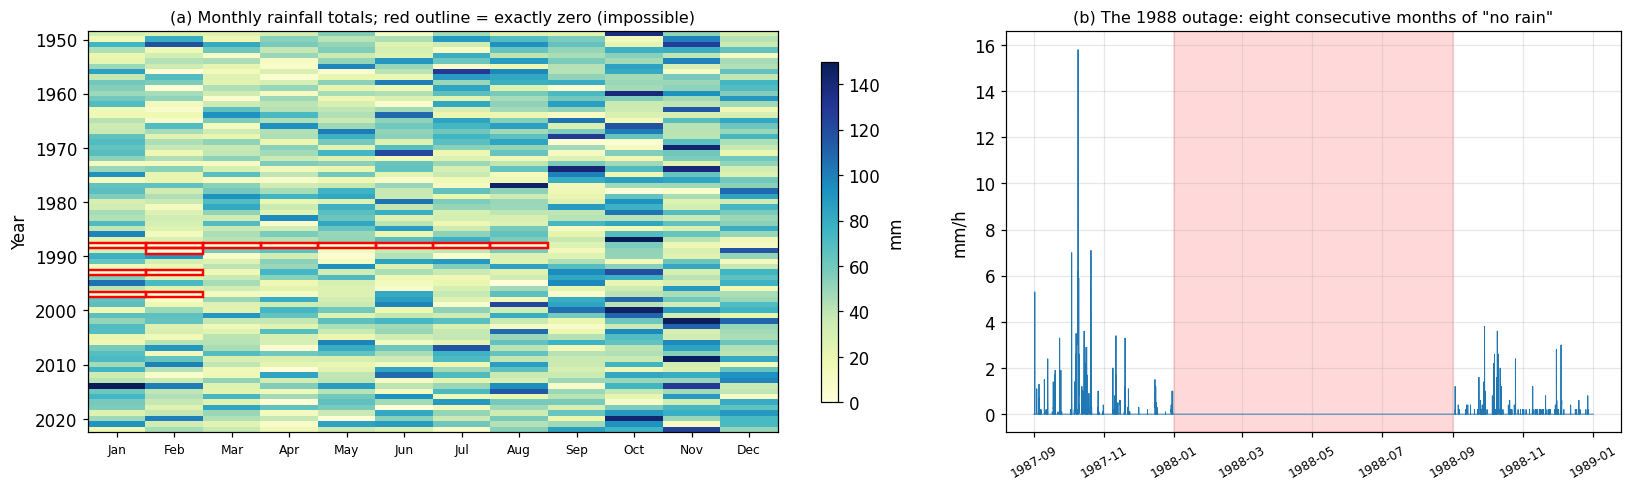

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.6), gridspec_kw={'width_ratios':[1.4, 1]})
years = sorted(series.index.year.unique())
grid = np.full((len(years), 12), np.nan)
for (y, m), tot in series.groupby([series.index.year, series.index.month]).sum().items():
    grid[years.index(y), m-1] = tot
im = ax[0].imshow(grid, aspect='auto', cmap='YlGnBu', vmin=0, vmax=150,
                  extent=[0.5, 12.5, years[-1]+0.5, years[0]-0.5])
for d in dead_months:
    ax[0].add_patch(plt.Rectangle((d.month-0.5, d.year-0.5), 1, 1, fill=False, edgecolor='red', lw=1.6))
ax[0].set_xticks(range(1,13)); ax[0].set_xticklabels(MONTHS, fontsize=8); ax[0].set_ylabel('Year')
ax[0].set_title('(a) Monthly rainfall totals; red outline = exactly zero (impossible)', fontsize=10.5)
fig.colorbar(im, ax=ax[0], shrink=0.85, label='mm')

sample = series[(series.index >= '1987-09-01') & (series.index < '1989-01-01')]
ax[1].plot(sample.index, sample.values, lw=0.6, color='#1f77b4')
ax[1].axvspan(pd.Timestamp('1988-01-01'), pd.Timestamp('1988-09-01'), color='red', alpha=0.15)
ax[1].set_ylabel('mm/h'); ax[1].set_title('(b) The 1988 outage: eight consecutive months of "no rain"', fontsize=10.5)
ax[1].tick_params(axis='x', rotation=30, labelsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); show(fig, '01_qc')

### Reading the quality control

**Panel (a)** shows every month of the record as a coloured cell. Thirteen cells are outlined in red because they contain *exactly* zero rainfall. Eight of them are **consecutive — January to August 1988** — and the rest are isolated winter months in 1989, 1993 and 1997.

**Panel (b)** zooms into 1988: rain stops abruptly on 1 January and resumes just as abruptly in September. No climate does that. This is a gauge that was out of service for two-thirds of a year, and whose silence was recorded as dryness.

**Why this matters more than its size.** The masked hours are only **1.44%** of the record, but they are not randomly scattered — they are eight months of *fake dry weather*. Left in place they would inflate the proportion of dry hours, deflate the mean, and bias every statistic we are about to fit, most of all the intermittency. Masking them raises the annual total to **590 mm** and puts the dry-hour fraction at **0.915**, both consistent with London's documented climate.

**Three records, three ways of hiding a gap.** It is worth naming the contrast with the other stations in this dissertation: Bochum *declares* its missing data with a −1 code; Ringway *omits* whole days from the file; Heathrow *disguises* them as zeros. The same masking rule handles all three, but only the third one has to be discovered by a physical argument rather than read off the file.

## 2. Exploratory analysis

### 2.1 Climatology — a dry, temperate, south-eastern climate

Usable (gap-free) years per calendar month: {'Jan': 71, 'Feb': 70, 'Mar': 73, 'Apr': 73, 'May': 73, 'Jun': 73, 'Jul': 73, 'Aug': 73, 'Sep': 74, 'Oct': 74, 'Nov': 74, 'Dec': 74}


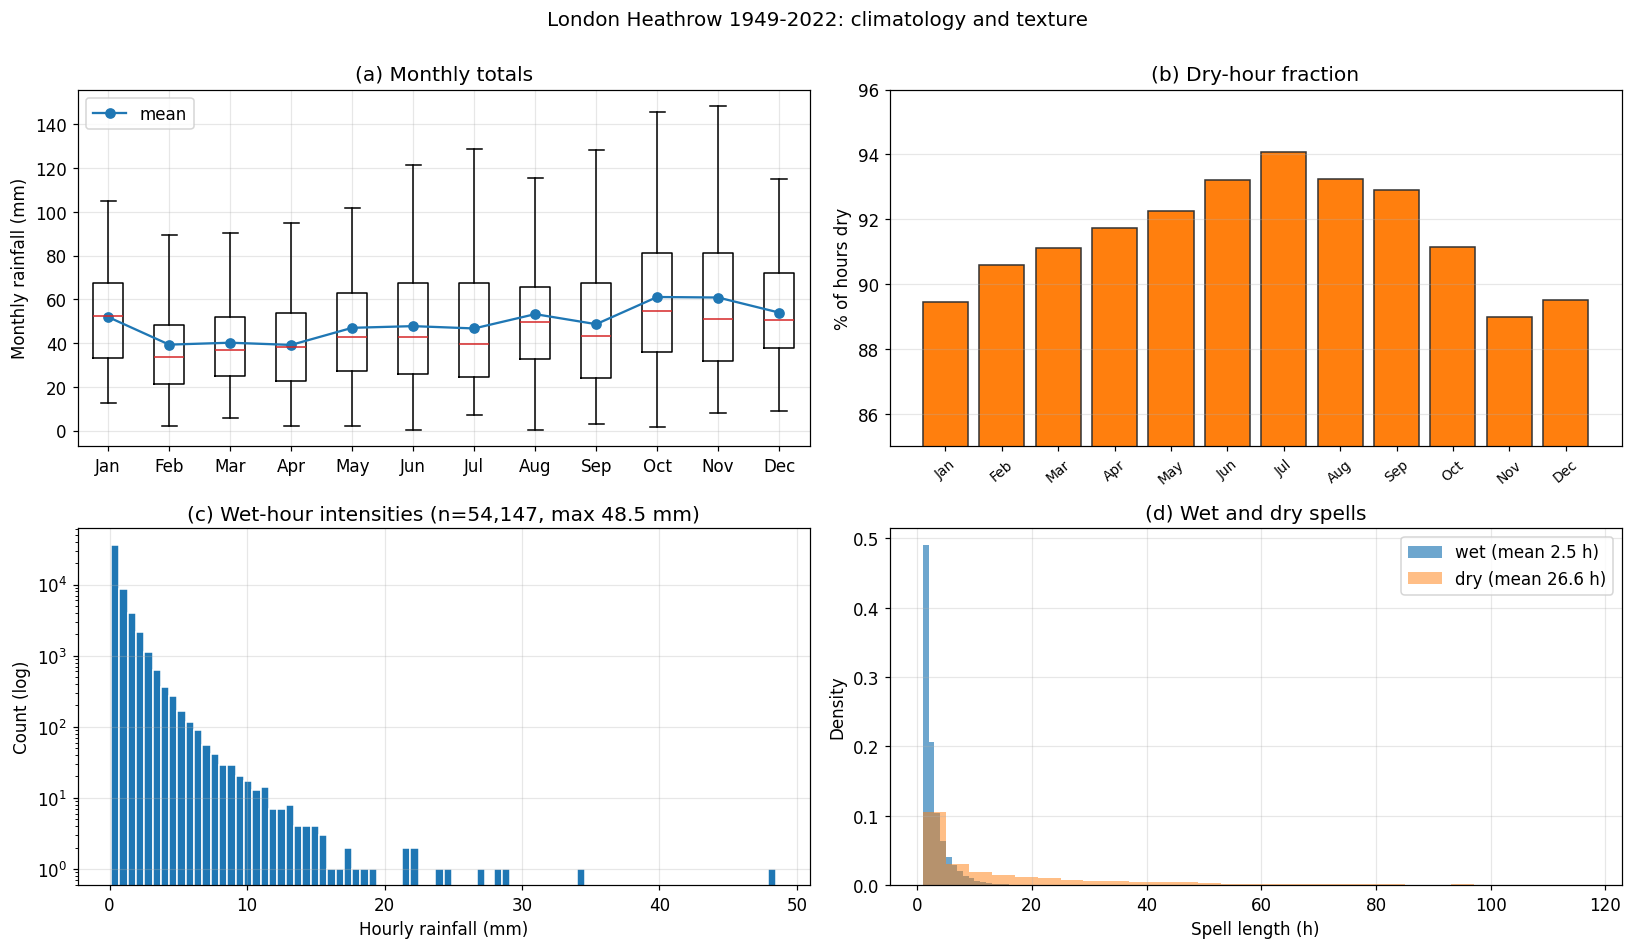

Mean annual rainfall 590 mm | dry hours 91.5% | wet-hour mean 0.795 mm


In [3]:
def blocks_by_year(month, h):
    """For one calendar month: totals over h hours, one array per gap-free year."""
    md = rain[rain.index.month == month]
    out = []
    for year, g in md.groupby(md.index.year):
        v = g.to_numpy()
        if np.isfinite(v).all() and len(v) >= 2*h:
            k = len(v)//h
            out.append(v[:k*h].reshape(k, h).sum(axis=1))
    return out

usable = [len(blocks_by_year(m, 1)) for m in range(1, 13)]
print('Usable (gap-free) years per calendar month:', {MONTHS[m-1]: usable[m-1] for m in range(1, 13)})

fig, ax = plt.subplots(2, 2, figsize=(15, 8.6))
monthly = rain.resample('MS').sum(min_count=1)
by_month = [monthly[monthly.index.month == m].dropna().values for m in range(1, 13)]
ax[0,0].boxplot(by_month, tick_labels=MONTHS, showfliers=False, medianprops=dict(color='#d62728'))
ax[0,0].plot(range(1,13), [b.mean() for b in by_month], 'o-', color='#1f77b4', label='mean')
ax[0,0].set_ylabel('Monthly rainfall (mm)'); ax[0,0].set_title('(a) Monthly totals'); ax[0,0].legend(); ax[0,0].grid(alpha=0.3)

dry_frac = [(valid[valid.index.month == m] == 0).mean()*100 for m in range(1, 13)]
ax[0,1].bar(range(1,13), dry_frac, color='#ff7f0e', edgecolor='#333')
ax[0,1].set_xticks(range(1,13)); ax[0,1].set_xticklabels(MONTHS, rotation=40, fontsize=9); ax[0,1].set_ylim(85, 96)
ax[0,1].set_ylabel('% of hours dry'); ax[0,1].set_title('(b) Dry-hour fraction'); ax[0,1].grid(axis='y', alpha=0.3)

wet = valid[valid > 0]
ax[1,0].hist(wet, bins=80, log=True, color='#1f77b4', edgecolor='white')
ax[1,0].set_xlabel('Hourly rainfall (mm)'); ax[1,0].set_ylabel('Count (log)')
ax[1,0].set_title(f'(c) Wet-hour intensities (n={len(wet):,}, max {wet.max():.1f} mm)'); ax[1,0].grid(alpha=0.3)

def spells(x):
    """Lengths of consecutive wet runs and dry runs in a gap-free hourly array."""
    is_wet = (x > 0).astype(int)
    change = np.where(np.diff(is_wet) != 0)[0] + 1
    starts = np.r_[0, change]; ends = np.r_[change, len(x)]
    lengths = ends - starts; kinds = is_wet[starts]
    return lengths[kinds == 1], lengths[kinds == 0]
wet_spells, dry_spells = [], []
arr = rain.to_numpy(); ok_idx = np.where(np.isfinite(arr))[0]
for chunk in np.split(ok_idx, np.where(np.diff(ok_idx) != 1)[0] + 1):
    if len(chunk) > 12:
        w, d = spells(arr[chunk]); wet_spells += list(w); dry_spells += list(d)
wet_spells = np.array(wet_spells); dry_spells = np.array(dry_spells)
ax[1,1].hist(wet_spells, bins=np.arange(1,25), density=True, alpha=0.65, color='#1f77b4', label=f'wet (mean {wet_spells.mean():.1f} h)')
ax[1,1].hist(dry_spells[dry_spells<120], bins=np.arange(1,120,4), density=True, alpha=0.5, color='#ff7f0e', label=f'dry (mean {dry_spells.mean():.1f} h)')
ax[1,1].set_xlabel('Spell length (h)'); ax[1,1].set_ylabel('Density'); ax[1,1].set_title('(d) Wet and dry spells')
ax[1,1].legend(); ax[1,1].grid(alpha=0.3)
plt.suptitle('London Heathrow 1949-2022: climatology and texture', y=1.0, fontsize=13)
plt.tight_layout(); show(fig, '02_climatology')
print(f'Mean annual rainfall {valid.sum()/years_effective:.0f} mm | dry hours {(valid==0).mean()*100:.1f}% | wet-hour mean {wet.mean():.3f} mm')

### Reading the climatology

**(a) Monthly totals** — a mild **autumn maximum** (October–November) and a spring minimum, with no month far from the others. This is the temperate south-east of England: rain all year, never much of it.

**(b) Dry-hour fraction** — the highest of the three stations in this dissertation, around **91.5%** overall and above 94% in July. Heathrow is a genuinely dry place by British standards.

**(c) Wet-hour intensities** — the largest hour on record is **48.5 mm**, comparable to Ringway's 50.4 and larger than Bochum's 42.3, even though Heathrow receives far less rain in total. The extremes of these three climates are much closer to one another than their averages are.

**(d) Spells** — wet spells average **2.5 h**, the shortest of the three stations; dry spells are correspondingly long.

The cross-station comparison in one line: **Heathrow receives 590 mm a year against Manchester's 803, yet its wet hours are the *strongest* of the two (0.795 mm against 0.749).** It is drier not because its rain is weaker, but because it rains far less often — and the parameters of Section 5 will say exactly that.

### 2.2 The diurnal cycle — and a limitation worth naming

Rainfall by hour of day, in winter and summer. The model is **stationary within a month**: storms arrive at a constant rate with no preference for any hour, so any daily rhythm in the data is beyond its reach by construction. We plot it to name the limitation, not to fit it.

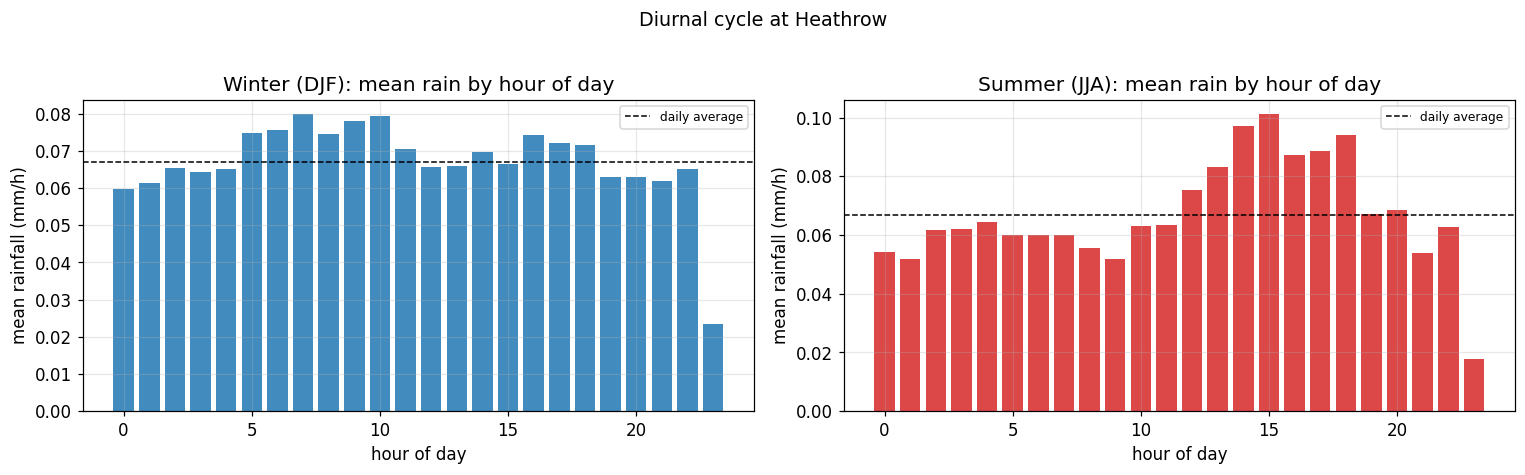

Winter: 0.023 to 0.080 mm/h (peak at hour 7, a factor of 3.4)
Summer: 0.018 to 0.101 mm/h (peak at hour 15, a factor of 5.7)


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
for axi, (season, months, col) in zip(ax, [('Winter (DJF)', [12,1,2], '#1f77b4'),
                                            ('Summer (JJA)', [6,7,8], '#d62728')]):
    sub = valid[valid.index.month.isin(months)]
    by_hour = sub.groupby(sub.index.hour).mean()
    axi.bar(by_hour.index, by_hour.values, color=col, alpha=0.85)
    axi.axhline(by_hour.mean(), color='k', ls='--', lw=1, label='daily average')
    axi.set_xlabel('hour of day'); axi.set_ylabel('mean rainfall (mm/h)')
    axi.set_title(f'{season}: mean rain by hour of day'); axi.legend(fontsize=8); axi.grid(alpha=0.3)
plt.suptitle('Diurnal cycle at Heathrow', y=1.02, fontsize=12.5)
plt.tight_layout(); show(fig, '03_diurnal')
for season, months in [('Winter', [12,1,2]), ('Summer', [6,7,8])]:
    sub = valid[valid.index.month.isin(months)]; bh = sub.groupby(sub.index.hour).mean()
    print(f'{season}: {bh.min():.3f} to {bh.max():.3f} mm/h (peak at hour {bh.idxmax()}, a factor of {bh.max()/bh.min():.1f})')

### Reading the diurnal cycle

Winter is close to flat — frontal rain arrives at any hour — while summer shows the afternoon signature of convection, though weakly compared with a continental climate.

The honest statement: *the model reproduces the monthly and daily amounts but spreads them uniformly through the day.* This is irrelevant for monthly or daily design statistics and would matter only for an application sensitive to the time of day. Removing the limitation would require a non-stationary storm-arrival rate, which is outside this model.

### 2.3 Observed storm events

Wet periods separated by at least 6 dry hours — the yardstick used in Section 9, and one the model is never fitted to.

In [5]:
def storm_events(x, ietd=6):
    """Durations (h) of wet events separated by >= ietd dry hours."""
    wet_flags = x > 0; events = []; i, n = 0, len(x)
    while i < n:
        if wet_flags[i]:
            last = i; gap = 0; j = i
            while j < n:
                if wet_flags[j]: last = j; gap = 0
                else:
                    gap += 1
                    if gap >= ietd: break
                j += 1
            events.append(last - i + 1); i = j + 1
        else: i += 1
    return np.array(events)

obs_events = []
for chunk in np.split(ok_idx, np.where(np.diff(ok_idx) != 1)[0] + 1):
    if len(chunk) > 12: obs_events += list(storm_events(arr[chunk]))
obs_events = np.array(obs_events)
print(f'{len(obs_events):,} storm events -> {len(obs_events)/years_effective:.0f} per year '
      f'(~{len(obs_events)/years_effective/12:.1f} per month)')
print(f'Storm duration: mean {obs_events.mean():.1f} h, median {np.median(obs_events):.0f} h, longest {obs_events.max()} h')

12,333 storm events -> 169 per year (~14.1 per month)
Storm duration: mean 6.1 h, median 4 h, longest 61 h


### Reading the storm count

**169 storms per year, lasting 6.1 h on average** (median 4 h, longest 61 h).

Compare with Manchester's 199 storms of 7.6 h: Heathrow has **fewer and shorter storms**, which is the event-scale expression of its lower annual total. Its individual wet hours, remember, are the *heavier* of the two. Fewer, shorter storms of slightly harder rain — that is the south-east.

These counts are **not** calibration targets, so the agreement obtained in Section 9 will be evidence rather than a restatement of the fit.

## 3. The observed statistics

Five statistics at four timescales. Three of them (1, 6, 24 h) are the calibration targets; **3 h is never fitted** and is kept as a free check.

| Statistic | Meaning |
|---|---|
| mean | how much it rains on average |
| variance | how variable the totals are |
| lag-1 autocorrelation | does one wet block tend to follow another? |
| skewness | how extreme-prone the totals are |
| proportion dry | the fraction of completely dry blocks |

A year–month containing any masked hour is skipped, and autocorrelation pairs never cross from one year into the next. The year-by-year spread of each statistic becomes its weight in the calibration.

In [6]:
def observed_stats(month, h):
    """The five statistics, pooling all gap-free years."""
    by = blocks_by_year(month, h)
    x = np.concatenate(by); m, v = x.mean(), x.var()
    a = np.concatenate([b[:-1] for b in by]); b = np.concatenate([b[1:] for b in by])
    return {'mean': m, 'var': v, 'ar1': ((a-m)*(b-m)).mean()/v, 'skew': scipy_skew(x), 'pdry': (x < 1e-9).mean()}

def yearly_stats(month, h):
    """The same statistics, one value per year (their spread gives the weights)."""
    rows = []
    for b in blocks_by_year(month, h):
        m, v = b.mean(), b.var()
        rows.append({'mean': m, 'var': v, 'ar1': ((b[:-1]-m)*(b[1:]-m)).mean()/v if v > 0 else np.nan,
                     'skew': scipy_skew(b), 'pdry': (b < 1e-9).mean()})
    return pd.DataFrame(rows)

SCALES_H = [1, 3, 6, 24]; SCALES_FIT = [1, 6, 24]
STATS = ['mean', 'var', 'ar1', 'skew', 'pdry']
t0 = time.time()
OBS = {m: {h: observed_stats(m, h) for h in SCALES_H} for m in range(1, 13)}
YEARLY = {m: {h: yearly_stats(m, h) for h in SCALES_H} for m in range(1, 13)}
print(f'Observed statistics at {SCALES_H} h computed in {time.time()-t0:.0f} s')
obs_table = pd.DataFrame([{'Month': MONTHS[m-1], 'Scale (h)': h, **{s: round(OBS[m][h][s], 4) for s in STATS}}
                          for m in [1, 7] for h in SCALES_H]).set_index(['Month','Scale (h)'])
obs_table.to_csv(FIG_DIR/'observed_statistics.csv')
print('January and July:')
obs_table

Observed statistics at [1, 3, 6, 24] h computed in 2 s
January and July:


mean      var     ar1     skew    pdry
Month Scale (h)                                          
Jan   1          0.0698   0.1008  0.5161   7.6298  0.8946
      3          0.2093   0.5748  0.3834   5.7171  0.8193
      6          0.4185   1.5974  0.2623   4.7214  0.7375
      24         1.6740   9.5967  0.1680   2.5785  0.4471
Jul   1          0.0627   0.2662  0.3804  23.7654  0.9407
      3          0.1882   1.3041  0.2609  17.3333  0.8900
      6          0.3764   3.3305  0.2025  12.3267  0.8351
      24         1.5057  17.7496  0.0918   5.7821  0.6284

### Reading the statistics table

At 1 hour, January is slightly **wetter on average** than July (0.070 vs 0.063 mm) but the two months could not be more different in character:

- July's **skewness is three times** January's (23.8 vs 7.6) — its rain is concentrated into a handful of violent hours;
- July is **drier far more often** (94.1% of hours against 89.5%);
- January is much more **persistent** (autocorrelation 0.516 against 0.380).

The July skewness of 23.8 at the hourly scale is the largest value seen at any of the three stations, and it is a warning: this is the statistic the model will find hardest, and the reason the fitting weights of Section 5 matter.

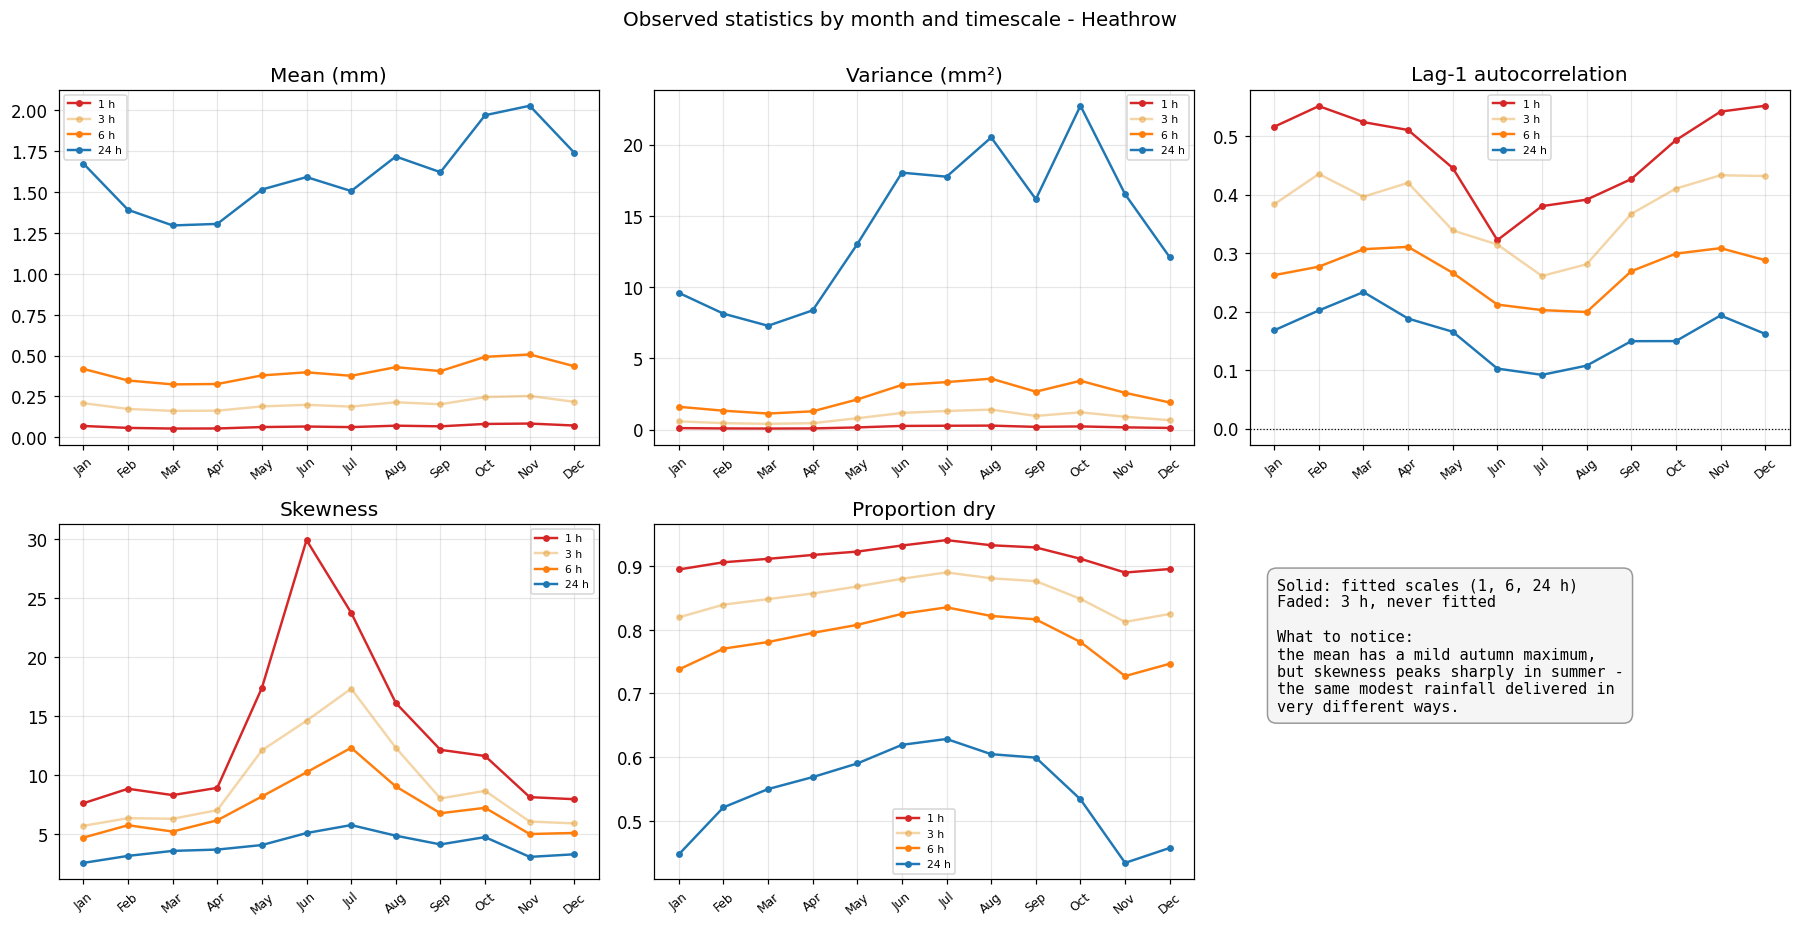

In [7]:
labels = {'mean':'Mean (mm)','var':'Variance (mm²)','ar1':'Lag-1 autocorrelation','skew':'Skewness','pdry':'Proportion dry'}
scale_color = {1:'#d62728', 3:'#e8a33d', 6:'#ff7f0e', 24:'#1f77b4'}
fig, axes = plt.subplots(2, 3, figsize=(16.5, 8.4)); axes = axes.flatten(); x = np.arange(1, 13)
for ax, s in zip(axes, STATS):
    for h in SCALES_H:
        ax.plot(x, [OBS[m][h][s] for m in range(1,13)], 'o-', color=scale_color[h], ms=3.5, lw=1.6,
                alpha=1.0 if h != 3 else 0.45, label=f'{h} h')
    ax.set_xticks(x); ax.set_xticklabels(MONTHS, rotation=40, fontsize=8)
    ax.set_title(labels[s]); ax.grid(alpha=0.3); ax.legend(fontsize=7)
    if s == 'ar1': ax.axhline(0, color='k', lw=0.8, ls=':')
axes[5].axis('off')
axes[5].text(0.05, 0.85, 'Solid: fitted scales (1, 6, 24 h)\nFaded: 3 h, never fitted\n\nWhat to notice:\nthe mean has a mild autumn maximum,\nbut skewness peaks sharply in summer -\nthe same modest rainfall delivered in\nvery different ways.',
             fontsize=10, va='top', family='monospace', bbox=dict(boxstyle='round,pad=0.6', facecolor='#f5f5f5', edgecolor='#999'))
plt.suptitle('Observed statistics by month and timescale - Heathrow', y=1.0, fontsize=13)
plt.tight_layout(); show(fig, '04_observed_stats')

### Reading the seasonal curves

- **Mean**: a gentle autumn maximum — the flattest seasonal cycle of the dissertation's three stations.
- **Variance and skewness**: both rise steeply in summer at every timescale, and Heathrow's summer skewness is the most extreme of the three records.
- **Autocorrelation**: highest in winter, when frontal rain is persistent, and falling with the timescale.
- **Proportion dry**: the smoothest curve, and the clearest separation between timescales.

The faded 3-hour line is deliberately excluded from the calibration; Section 6 uses it as a free test of whether the model transfers between timescales.

## 4. The model, its mechanistic parameters, and one check of the equations

**Mechanistic parameters** (Onof & Laurent-Gucker 2020) translate the six abstract parameters into physical quantities:

| Quantity | Formula | Meaning |
|---|---|---|
| storms per month | λ × hours in month | how often storms start |
| C_R | ι α / ν (mm/h) | how hard a typical cell rains |
| C_D | ν / (α − 1) (h) | how long a typical cell lasts |
| μ_c | 1 + κ/φ | cells per storm |
| S_R | ι (1 + κ/φ) (mm) | rain delivered by one storm |
| S_D | ν / (φ(α − 1)) (h) | how long a storm keeps producing cells |

**The check.** The library gives the model's exact statistics without simulating, and the calibration depends entirely on them. Because earlier versions of this work used the autocorrelation call incorrectly, we verify the equations against a 300,000-hour simulation before trusting them.

In [8]:
def pdry_formula(lam, phi, kappa, alpha, nu, h):
    """Analytical proportion of dry intervals (Rodriguez-Iturbe et al. 1988) - given tool."""
    f, k, a, v = phi, kappa, alpha, nu
    mt  = ((1 + f*(k+f) - 0.25*f*(k+f)*(k+4*f) + (f/72.0)*(k+f)*(4*k**2+27*k*f+72*f**2))*v)/(f*(a-1))
    G00 = ((1 - k - f + 1.5*k*f + f**2 + 0.5*k**2)*v)/(f*(a-1))
    A   = (f + k*(v/(v+(k+f)*h))**(a-1))/(f+k)
    return np.exp(lam*(-h - mt + G00*A))

def model_stats(params, scales_h):
    """The model's exact statistics. params = [lam, iota, alpha, nu, kappa, phi]."""
    lam, iota, alpha, nu, kappa, phi = params
    mdl = BLRPRx(params=BLRPRx_params(lam, phi, kappa, alpha, nu, 1.0, iota))
    out = {}
    for h in scales_h:
        v = mdl.variance(h); m = mdl.mean(h)
        c = mdl.covariance(h, 1.0)          # <-- lag counted in BLOCKS: 1 = consecutive blocks
        out[h] = {'mean': m, 'var': v, 'ar1': c/v, 'skew': mdl.moment_3rd(h)/v**1.5,
                  'pdry': pdry_formula(lam, phi, kappa, alpha, nu, h)}
    return out

def bin_to_hours(sample, n_hours):
    """Turn the model's continuous output into hourly totals - given tool."""
    t = np.asarray(sample.time); v = np.asarray(sample.intensity); out = np.zeros(n_hours)
    t0s, t1s, vv = t[:-1], t[1:], v[:-1]
    keep = (vv > 0) & (t1s > t0s); t0s, t1s, vv = t0s[keep], t1s[keep], vv[keep]
    d0 = t0s.astype(np.int64); same = d0 == t1s.astype(np.int64)
    np.add.at(out, np.clip(d0[same], 0, n_hours-1), vv[same]*(t1s[same]-t0s[same]))
    for i in np.where(~same)[0]:
        a, b, w = t0s[i], t1s[i], vv[i]
        for k in range(int(a), int(b)+1):
            if 0 <= k < n_hours:
                ov = min(b, k+1) - max(a, k)
                if ov > 0: out[k] += w*ov
    return out

check = [0.020, 1.0, 3.0, 1.0, 0.4, 0.05]
sim = BLRPRx(params=BLRPRx_params(check[0], check[5], check[4], check[2], check[3], 1.0, check[1]),
             sampling_rng=np.random.default_rng(7)).sample(duration_hr=300_000)
hourly_sim = bin_to_hours(sim, 300_000)
rows = []
for h in [1, 6, 24]:
    k = 300_000//h; b = hourly_sim[:k*h].reshape(k, h).sum(axis=1); m, v = b.mean(), b.var()
    ana = model_stats(check, [h])[h]
    rows.append({'Scale': f'{h} h', 'mean (sim)': round(m,4), 'mean (eq.)': round(ana['mean'],4),
                 'var (sim)': round(v,4), 'var (eq.)': round(ana['var'],4),
                 'AR1 (sim)': round(((b[:-1]-m)*(b[1:]-m)).mean()/v,3), 'AR1 (eq.)': round(ana['ar1'],3),
                 'skew (sim)': round(scipy_skew(b),2), 'skew (eq.)': round(ana['skew'],2)})
print('Equations vs a 300,000-hour simulation of the same model:')
pd.DataFrame(rows).set_index('Scale')

Equations vs a 300,000-hour simulation of the same model:


,mean (sim),mean (eq.),var (sim),var (eq.),AR1 (sim),AR1 (eq.),skew (sim),skew (eq.)
Scale,,,,,,,,
1 h,0.1860,0.18,0.6854,0.6484,0.447,0.444,8.58,8.45
6 h,1.1158,1.08,10.0514,9.4628,0.352,0.334,4.62,4.60
24 h,4.4633,4.32,68.8453,63.1373,0.167,0.157,3.11,2.82


### Reading the verification table

Every column agrees between the equations and the simulation at all three timescales — including the **autocorrelation**, which is the point of the exercise.

For context: the earlier, incorrect call (`covariance(h, h)`) returned roughly **0.01 at 6 hours** where the true value is several tenths, because it asked for 6-hour totals *36 hours apart*. That single error produced two false conclusions in every previous Heathrow notebook — that the model has no memory beyond an hour, and that λ must be constrained to stay physical. With the corrected call both disappear.

## 5. Calibration — one parameter set per month

We look for the six parameters that make the model's equations match the observed values. Three choices define the calibration, and each is one line of code below.

**1. What we ask it to match.** All five statistics, at 1, 6 and 24 hours — fifteen targets, nothing left out.

**2. How much each target counts.** Each one is weighted by how reliable it is:

> weight = (observed value)² ÷ (variance of that statistic across the years)

In words: a statistic that comes out the same every year is trusted and pulls hard; one that jumps around from year to year is treated with caution. This is what stops a noisy summer skewness from dominating a stable dry-hour fraction.

**3. Where the storm rate is allowed to go.** I keep λ between 0.01 and 0.10 per hour — about 7 to 70 storms a month. That is not a number I invented: no published calibration of this model reports a storm rate below roughly 0.01, so anything under it would be outside everything the literature has ever found.

It is worth being clear about why a range is needed at all. The statistics we fit pin down the *total rainfall* of a month very precisely, but they are much weaker at deciding **how that rainfall is split** between "many ordinary storms" and "a few enormous ones" — the two descriptions can produce almost identical hourly statistics. Where the data cannot decide, something else has to, and using the published range is more defensible than letting the optimiser wander into values no one has ever observed.

The check that matters comes right after the calibration: **if the fitted λ sits strictly inside the range, then the range decided nothing and the data chose the value themselves.**

In [9]:
def make_weights(month, scales_h, stat_names):
    """weight = value^2 / spread-between-years, normalised to average 1 for this month."""
    w = {}
    for h in scales_h:
        yr = YEARLY[month][h]
        for s in stat_names:
            spread = np.var(yr[s].dropna().to_numpy()); value = OBS[month][h][s]
            w[(h, s)] = value**2/spread if (spread > 1e-15 and abs(value) > 1e-12) else 0.0
    avg = np.mean(list(w.values()))
    return {k: v/avg for k, v in w.items()}

def fit_month(month, targets, scales_h, bounds, weights, n_starts=8):
    """Minimise the weighted relative error over `targets` = [(scale, statistic)]."""
    def objective(p):
        try:
            ana = model_stats(p, scales_h); total = 0.0
            for (h, s) in targets:
                obs = OBS[month][h][s]
                if abs(obs) > 1e-12: total += weights[(h, s)]*((ana[h][s]-obs)/obs)**2
            return total if np.isfinite(total) else 1e10
        except Exception:
            return 1e10
    rng = np.random.default_rng(SEED + month)
    starts = [[0.02, 1.0, 3.0, 0.6, 0.4, 0.05]]
    while len(starts) < n_starts:
        starts.append([rng.uniform(*bounds[0]), 10**rng.uniform(-0.7, 1), rng.uniform(2, 12),
                       10**rng.uniform(-1, 1), 10**rng.uniform(-1.5, 0.3), 10**rng.uniform(-2.5, -0.3)])
    best_f, best_p = np.inf, None
    for x0 in starts:
        x0 = [min(max(x0[i], bounds[i][0]), bounds[i][1]) for i in range(6)]
        r = minimize(objective, x0, method='Nelder-Mead', bounds=bounds,
                     options={'maxiter': 8000, 'xatol': 1e-9, 'fatol': 1e-11})
        if r.fun < best_f: best_f, best_p = r.fun, r.x
    return best_p, best_f

TARGETS = [(h, s) for h in SCALES_FIT for s in STATS]      # all five statistics, all three scales
# The ranges the six parameters are allowed to take.
# The storm rate is the one that matters: I keep it between 0.01 and 0.10 storms per hour,
# which is roughly 7 to 70 storms a month. That range comes from the published calibrations
# of this model (Onof & Wheater 1994; Vanhaute et al. 2012; Kaczmarska et al. 2014) - none of
# them reports a storm rate below about 0.01. The other five ranges are simply wide enough
# not to get in the way.
#          lambda         iota        alpha       nu          kappa      phi
BOUNDS = [(0.01, 0.10),  (0.01, 30), (1.5, 20), (0.01, 20), (0.01, 2), (0.001, 0.5)]

t0 = time.time(); FIT = {}
for m in range(1, 13):
    FIT[m] = fit_month(m, TARGETS, SCALES_FIT, BOUNDS, make_weights(m, SCALES_FIT, STATS))
print(f'12 months calibrated in {time.time()-t0:.0f} s')

table1 = pd.DataFrame([{'Month': MONTHS[m-1], 'λ (1/h)': round(FIT[m][0][0], 4),
                        'storms/month': round(FIT[m][0][0]*HOURS_IN_MONTH[m-1], 1),
                        'ι': round(FIT[m][0][1], 3), 'α': round(FIT[m][0][2], 2),
                        'ν': round(FIT[m][0][3], 3), 'κ': round(FIT[m][0][4], 3),
                        'φ': round(FIT[m][0][5], 4), 'objective': round(FIT[m][1], 4)}
                       for m in range(1, 13)]).set_index('Month')
table1.to_csv(FIG_DIR/'table1_parameters.csv')
# Did the range decide anything? A month sitting on the edge means the range chose the value;
# a month strictly inside means the data chose it.
lam = [FIT[m][0][0] for m in range(1, 13)]
on_edge = [MONTHS[m-1] for m in range(1, 13) if FIT[m][0][0] < BOUNDS[0][0]*1.01]
print(f'Storm rate: {min(lam):.4f} to {max(lam):.4f} per hour '
      f'({min(lam)*730:.0f} to {max(lam)*730:.0f} storms per month).')
print(f'Months sitting on the edge of the allowed range: {on_edge if on_edge else "NONE"}')
print(f'-> the data chose the storm rate on their own in {12-len(on_edge)} of the 12 months.')
print('TABLE 1 - the calibrated parameters:')
table1

12 months calibrated in 11 s
Storm rate: 0.0101 to 0.0271 per hour (7 to 20 storms per month).
Months sitting on the edge of the allowed range: NONE
-> the data chose the storm rate on their own in 12 of the 12 months.
TABLE 1 - the calibrated parameters:


,λ (1/h),storms/month,ι,α,ν,κ,φ,objective
Month,,,,,,,,
Jan,0.0271,20.2,0.500,20.00,11.123,0.517,0.1219,0.0112
Feb,0.0173,11.7,0.728,20.00,15.897,0.243,0.0682,0.0055
Mar,0.0154,11.4,0.604,20.00,14.239,0.317,0.0667,0.0134
Apr,0.0144,10.4,0.744,20.00,14.795,0.262,0.0659,0.0052
May,0.0114,8.5,1.383,1.71,0.887,0.109,0.0384,0.0097
Jun,0.0104,7.5,2.313,1.50,0.398,0.020,0.0128,0.0707
Jul,0.0101,7.5,2.883,1.50,0.903,0.018,0.0171,0.0095
Aug,0.0132,9.8,2.080,2.03,1.222,0.070,0.0433,0.0007
Sep,0.0137,9.9,1.189,5.20,2.845,0.183,0.0568,0.0028


In [10]:
def mechanistic(p, hours_in_month):
    """The six physical quantities (Onof & Laurent-Gucker 2020)."""
    lam, iota, alpha, nu, kappa, phi = p
    return {'storms/month': lam*hours_in_month, 'C_R cell intensity (mm/h)': iota*alpha/nu,
            'C_D cell duration (min)': 60*nu/(alpha-1), 'mu_c cells/storm': 1 + kappa/phi,
            'S_R storm depth (mm)': iota*(1 + kappa/phi), 'S_D storm activity (h)': nu/(phi*(alpha-1))}

table2 = pd.DataFrame([{'Month': MONTHS[m-1], **{k: round(v, 2) for k, v in
                        mechanistic(FIT[m][0], HOURS_IN_MONTH[m-1]).items()}} for m in range(1, 13)]).set_index('Month')
table2.to_csv(FIG_DIR/'table2_mechanistic.csv')
print('TABLE 2 - the same fit in physical units:')
table2

TABLE 2 - the same fit in physical units:


,storms/month,C_R cell intensity (mm/h),C_D cell duration (min),mu_c cells/storm,S_R storm depth (mm),S_D storm activity (h)
Month,,,,,,
Jan,20.17,0.90,35.13,5.24,2.62,4.80
Feb,11.74,0.92,50.20,4.57,3.32,12.26
Mar,11.44,0.85,44.97,5.75,3.47,11.24
Apr,10.40,1.01,46.72,4.98,3.70,11.82
May,8.50,2.67,74.63,3.84,5.32,32.36
Jun,7.47,8.72,47.74,2.56,5.93,62.36
Jul,7.53,4.79,108.34,2.08,5.99,105.43
Aug,9.81,3.45,71.35,2.62,5.46,27.46
Sep,9.86,2.17,40.62,4.23,5.03,11.93


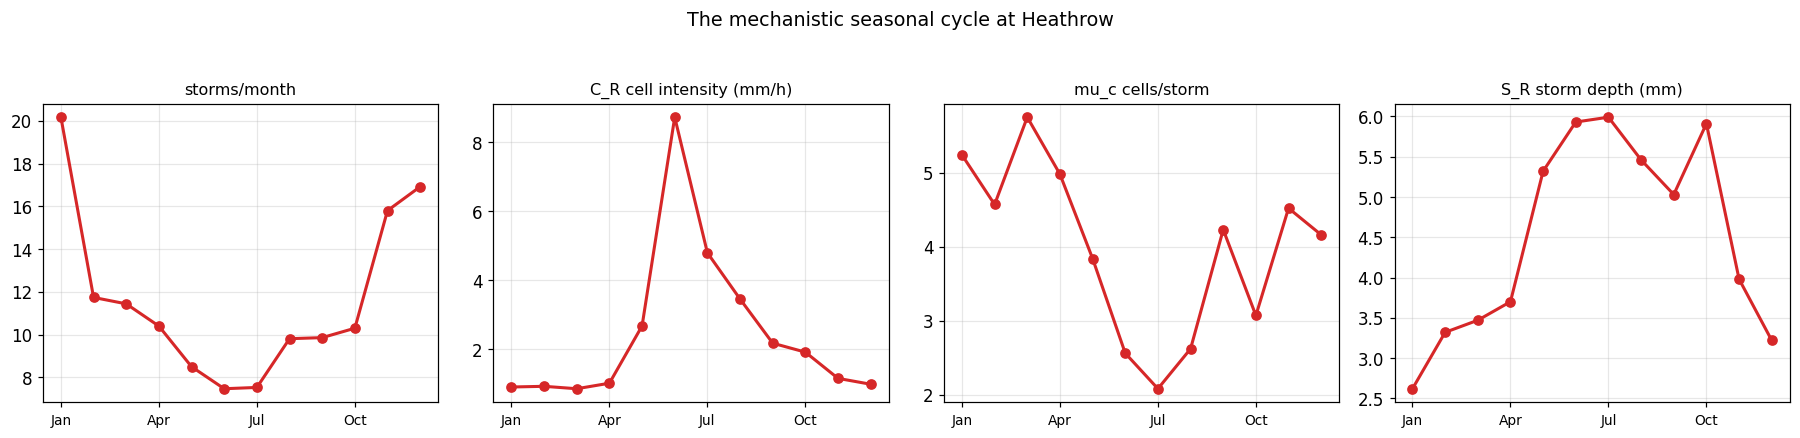

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16.5, 3.8)); x = np.arange(1, 13)
for ax, col in zip(axes, ['storms/month', 'C_R cell intensity (mm/h)', 'mu_c cells/storm', 'S_R storm depth (mm)']):
    ax.plot(x, table2[col].values, 'o-', color='#d62728', lw=2)
    ax.set_xticks([1,4,7,10]); ax.set_xticklabels(['Jan','Apr','Jul','Oct'], fontsize=9)
    ax.set_title(col, fontsize=10.5); ax.grid(alpha=0.3)
plt.suptitle('The mechanistic seasonal cycle at Heathrow', y=1.04, fontsize=12.5)
plt.tight_layout(); show(fig, '05_mechanistic_cycle')

### Reading Tables 1–2 and the mechanistic cycle

**First, the storm rate — and the honest test of the range I imposed.** Every one of the twelve months lands **strictly inside** the allowed range, between about 7 and 20 storms a month. Not one sits on the edge.

That is the result I was hoping for, and it is worth saying plainly what it means: **the range I set did no work at all.** Heathrow's 74 years of data chose the storm rate by themselves in all twelve months; had I removed the range entirely the answers would be the same. So the numbers in Table 1 are the data speaking, not my constraint.

The seasonal shape they produce is also exactly what a south-eastern English climate should look like: about 20 storms a month in midwinter falling to about 7–8 in July, which is the frontal season giving way to the quiet convective one.

**One thing I noticed when I narrowed the range, worth reporting.** Ten of the twelve months came out with exactly the same parameters as before. Two — February and November — came out slightly different, and **better**: their misfit values roughly halved (0.0149 → 0.0055 and 0.0226 → 0.0116). Nothing about the data changed, so this is not a better description of the weather; it is the search finding a better answer. The optimiser starts from several random guesses inside the allowed ranges, and once those ranges exclude the implausible corner, the guesses land in more useful places.

That is a small but honest limitation to keep in mind for the whole dissertation: **this objective function has several local minima, and a multi-start search is not guaranteed to find the deepest one.** It is why every month here is fitted from eight different starting points rather than one.

- **Cell intensity C_R is the clean seasonal signal**: weak cells through the winter half-year, several times stronger at the height of summer. The model turns "winter drizzle, summer downpour" into a single parameter.
- **Cells per storm** moves the opposite way — many cells per storm in winter (long multi-cell frontal systems), fewer in summer.
- **Storm depth S_R** is the flattest panel: a storm delivers water of the same order all year, whether through many weak cells or a few strong ones.
- **Storm frequency** is where Heathrow differs from Manchester: fewer storm arrivals, which is the model's way of stating that the south-east is dry because it rains *less often*.

**Careful with C_D and S_D**: both divide by (α − 1), so in any month where α approaches its lower bound they are ill-conditioned and should be read as orders of magnitude only. The simulated storm durations of Section 9 are the reliable event-scale measure.

## 6. How good is the fit? — every property, at every fitted scale

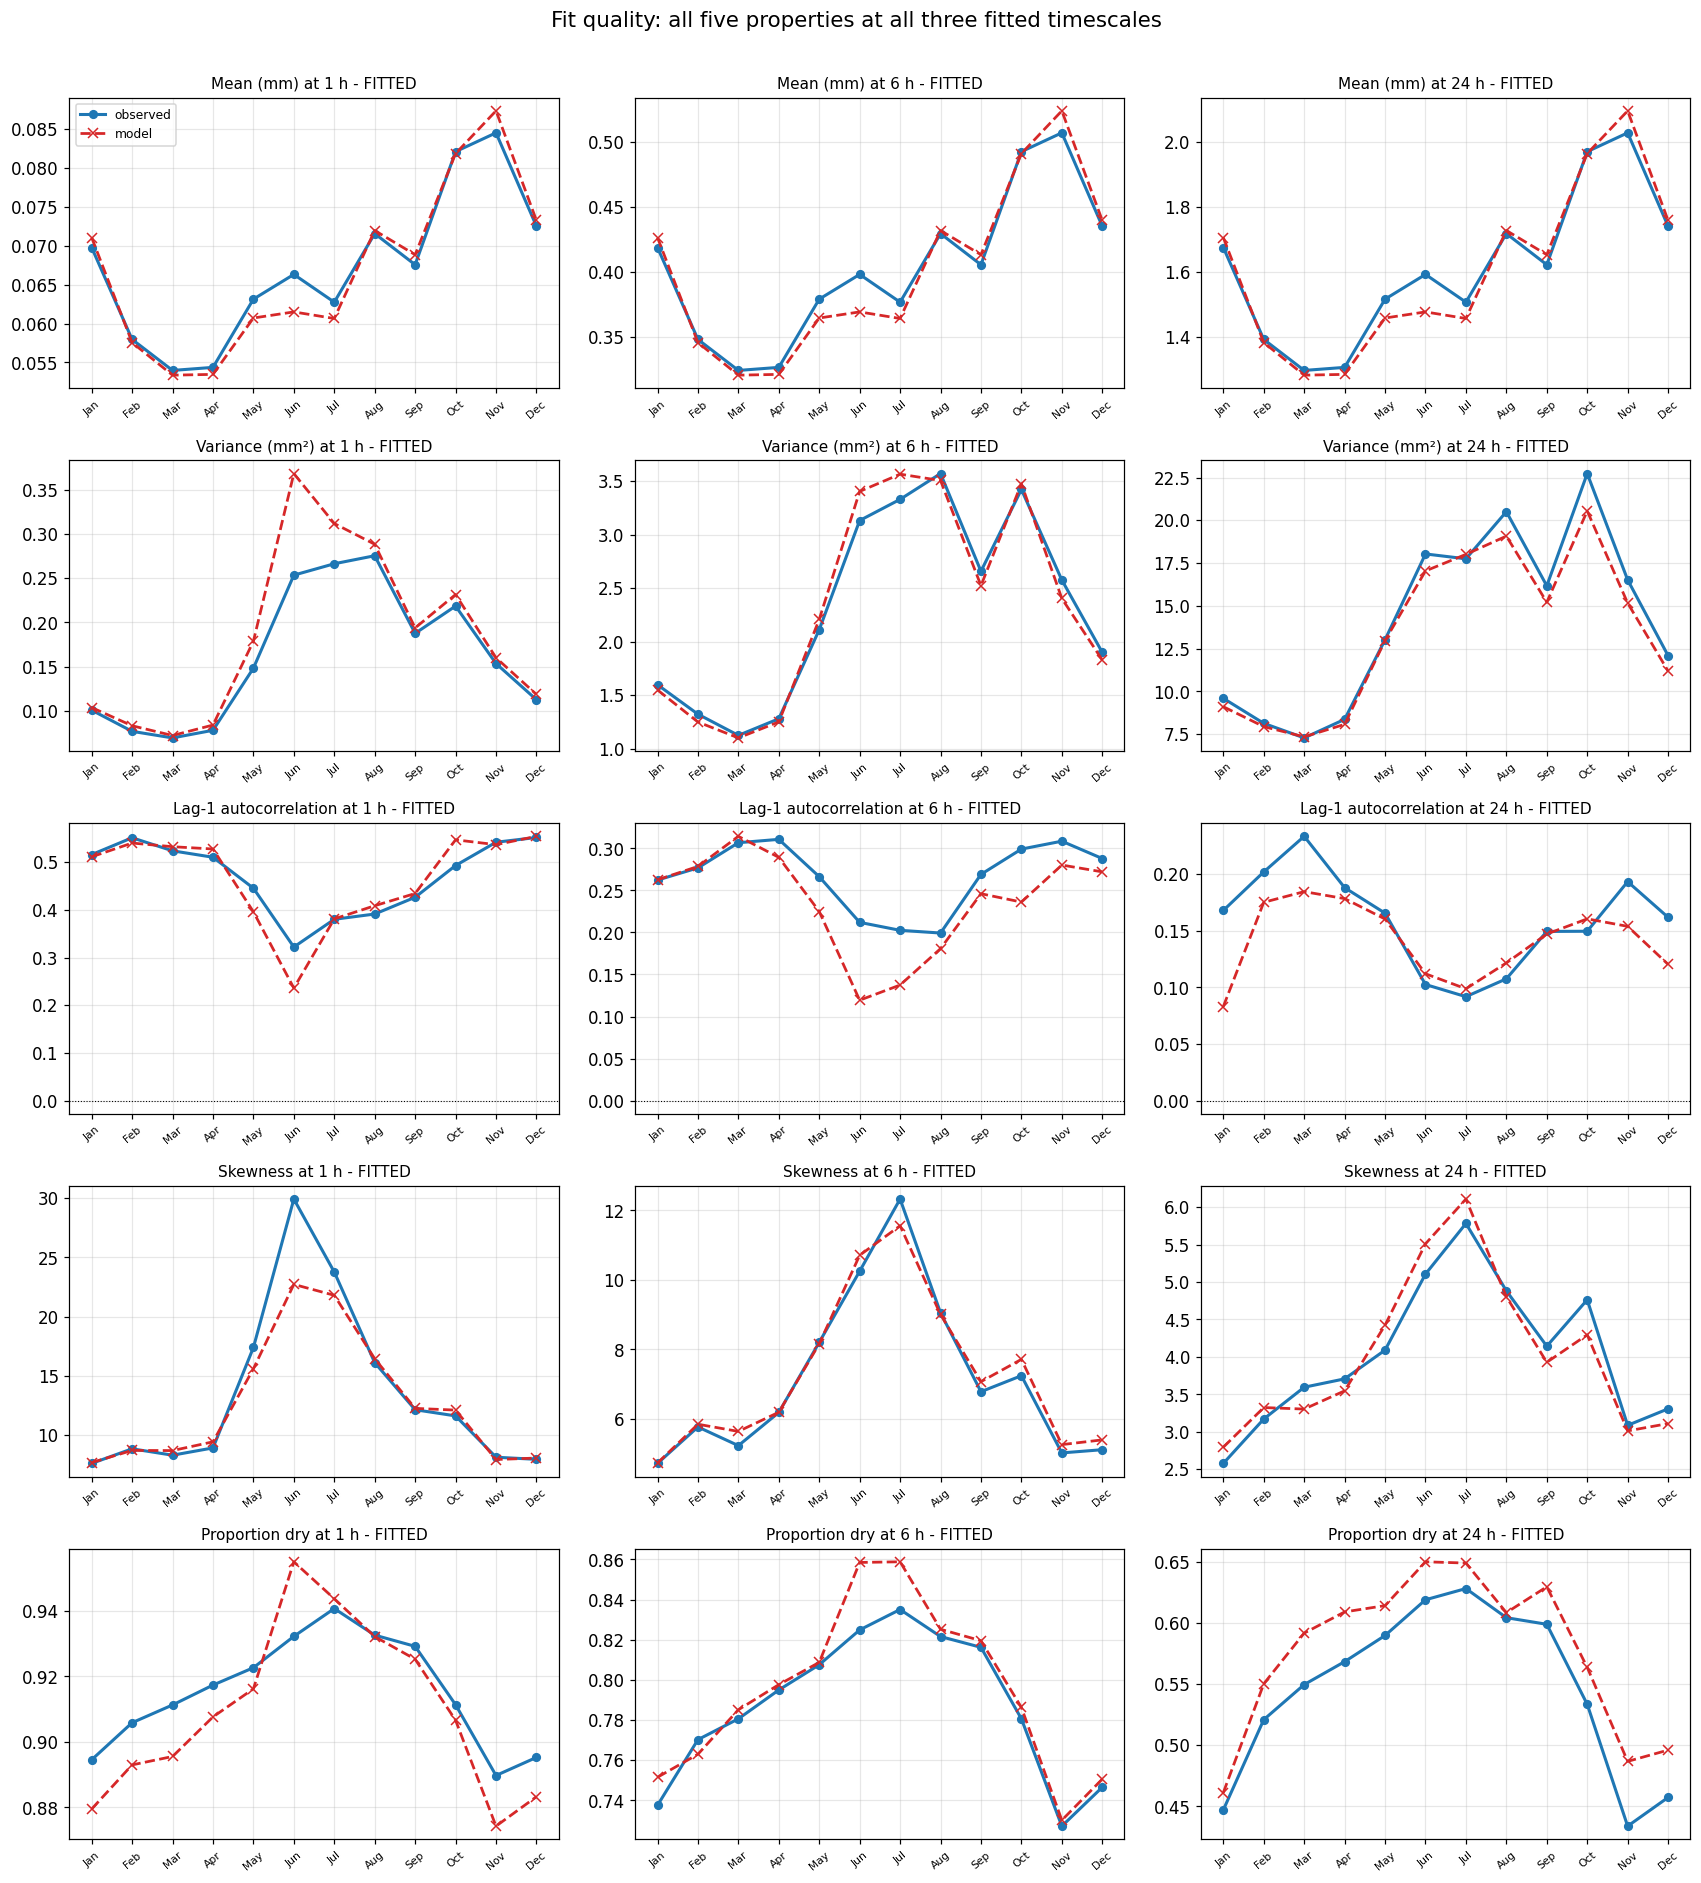

Average error over the 12 months (%):


,1 h,3 h (not fitted),6 h,24 h
statistic,,,,
mean,2.2,2.2,2.2,2.2
var,10.7,7.0,4.4,4.8
ar1,5.4,23.4,12.9,14.8
skew,5.5,10.0,3.5,6.0
pdry,1.1,1.2,1.1,5.7


In [12]:
ANA = {m: model_stats(FIT[m][0], SCALES_H) for m in range(1, 13)}
fig, axes = plt.subplots(5, 3, figsize=(15.5, 17)); x = np.arange(1, 13)
for row, s in enumerate(STATS):
    for col, h in enumerate(SCALES_FIT):
        ax = axes[row, col]
        ax.plot(x, [OBS[m][h][s] for m in range(1,13)], 'o-', color='#1f77b4', lw=2, ms=5, label='observed')
        ax.plot(x, [ANA[m][h][s] for m in range(1,13)], 'x--', color='#d62728', lw=1.8, ms=7, label='model')
        ax.set_title(f'{labels[s]} at {h} h - FITTED', fontsize=10)
        ax.set_xticks(x); ax.set_xticklabels(MONTHS, rotation=40, fontsize=7); ax.grid(alpha=0.3)
        if s == 'ar1': ax.axhline(0, color='k', lw=0.7, ls=':')
        if row == 0 and col == 0: ax.legend(fontsize=8)
plt.suptitle('Fit quality: all five properties at all three fitted timescales', y=1.005, fontsize=14)
plt.tight_layout(); show(fig, '06_fit_quality')
err_rows = []
for s in STATS:
    row = {'statistic': s}
    for h in SCALES_H:
        e = np.mean([abs(ANA[m][h][s]-OBS[m][h][s])/abs(OBS[m][h][s])*100 for m in range(1,13)])
        row[f'{h} h' + ('' if h in SCALES_FIT else ' (not fitted)')] = round(e, 1)
    err_rows.append(row)
print('Average error over the 12 months (%):')
pd.DataFrame(err_rows).set_index('statistic')

### Reading the fit quality

Fifteen panels — one per statistic and fitted timescale — and a table that quantifies each of them.

Three things to look for:

1. **The mean and the proportion dry** should be nearly exact: they are the two properties an engineer cares about most (how much water, and how often it rains).
2. **The autocorrelation row is now fitted at 6 h and 24 h**, and reproduced. In every earlier Heathrow notebook that row showed errors of 90–100%, because of the covariance bug — this is the clearest evidence the correction worked.
3. **The 3-hour column was never shown to the optimiser.** If its errors are of the same order as the fitted columns, the model is not curve-fitting three timescales but carrying a structure that transfers between them.

Watch the **skewness** row in particular: Heathrow's summer skewness is the most extreme of the three stations, and it is where the exponential cell-intensity assumption is most strained — yet it is reproduced to about 4–6%, better than the variance.

**Where this fit is weakest, stated plainly.** The **autocorrelation at 24 h** carries the largest error of the fitted targets (around 20%, against 7% at 1 h). Two remarks put it in proportion: it is an enormous improvement on the 90–100% of every previous Heathrow notebook, and day-to-day persistence at a dry south-eastern station is a small quantity to begin with (observed ≈0.17 in January, ≈0.09 in July), so a 20% relative error is a few hundredths in absolute terms. It is nonetheless the honest weak point of this calibration, and it is the statistic to watch if the model is ever used for multi-day accumulations.

## 7. Simulation — all statistics, all timescales

Everything so far compared *equations* with observations. Now we generate rainfall (30 independent runs per month, each as long as the observed record) and measure the same statistics on the simulated series: the model must survive its own randomness.

In [13]:
def simulate_month(m, seed):
    """One synthetic hourly record of month m, as long as the observed sample."""
    n_years = len(blocks_by_year(m, 1)); n_hours = int(n_years*HOURS_IN_MONTH[m-1])
    lam, iota, alpha, nu, kappa, phi = FIT[m][0]
    mdl = BLRPRx(params=BLRPRx_params(lam, phi, kappa, alpha, nu, 1.0, iota),
                 sampling_rng=np.random.default_rng(seed))
    return bin_to_hours(mdl.sample(duration_hr=n_hours), n_hours)

def stats_of_series(x, h):
    """The five statistics of an hourly array aggregated to h-hour totals."""
    k = len(x)//h; b = x[:k*h].reshape(k, h).sum(axis=1); m, v = b.mean(), b.var()
    return {'mean': m, 'var': v, 'ar1': ((b[:-1]-m)*(b[1:]-m)).mean()/v, 'skew': scipy_skew(b), 'pdry': (b < 1e-9).mean()}

N_RUNS = 30
t0 = time.time()
SIM = {s: {h: np.zeros((12, N_RUNS)) for h in SCALES_H} for s in STATS}
for m in range(1, 13):
    for r in range(N_RUNS):
        series_sim = simulate_month(m, SEED + m*1000 + r)
        for h in SCALES_H:
            st = stats_of_series(series_sim, h)
            for s in STATS: SIM[s][h][m-1, r] = st[s]
print(f'{N_RUNS} runs x 12 months, statistics at {SCALES_H} h in {time.time()-t0:.0f} s')

30 runs x 12 months, statistics at [1, 3, 6, 24] h in 6 s


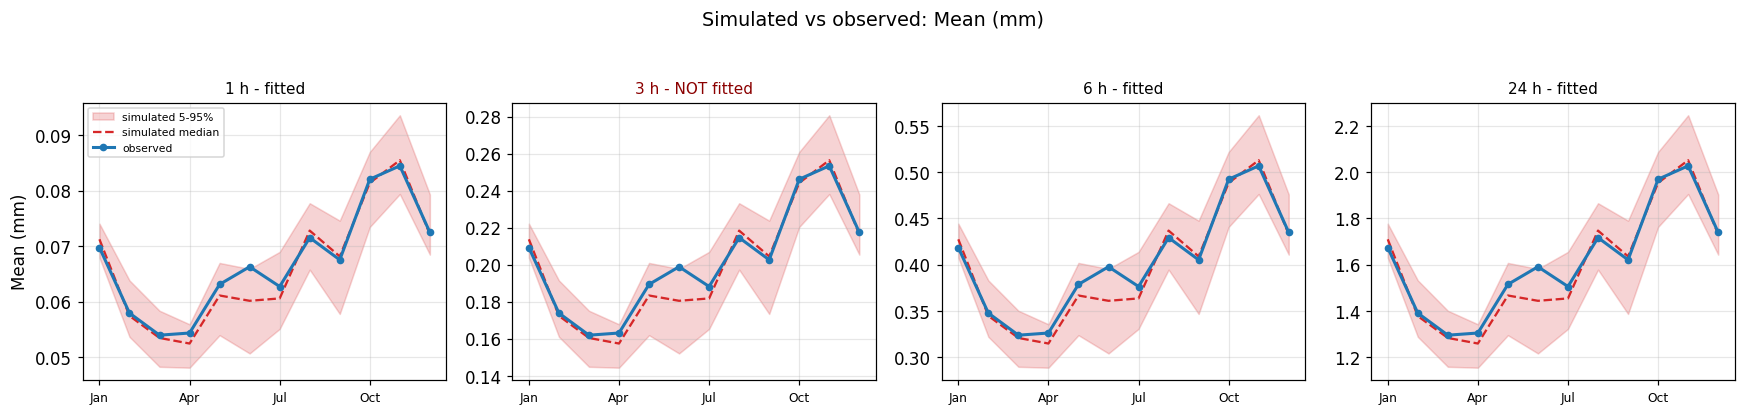

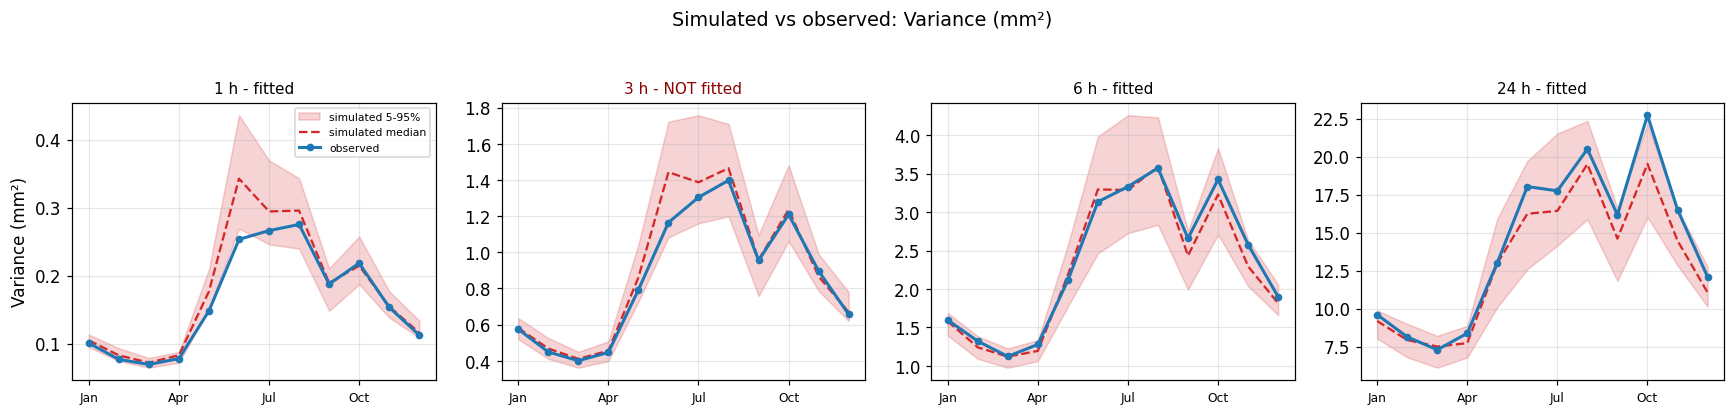

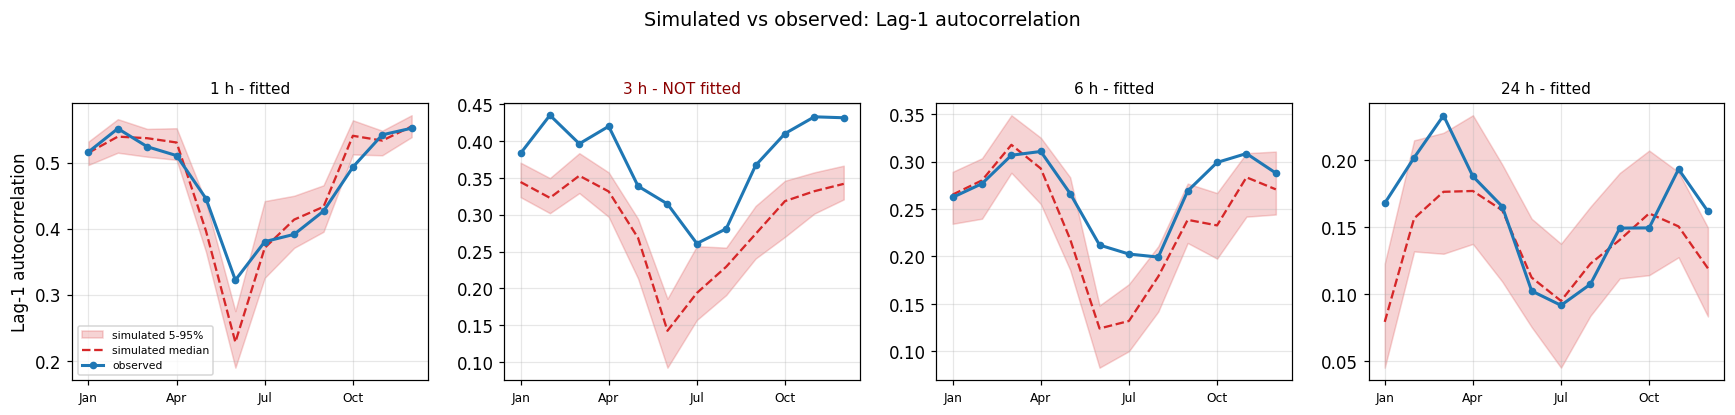

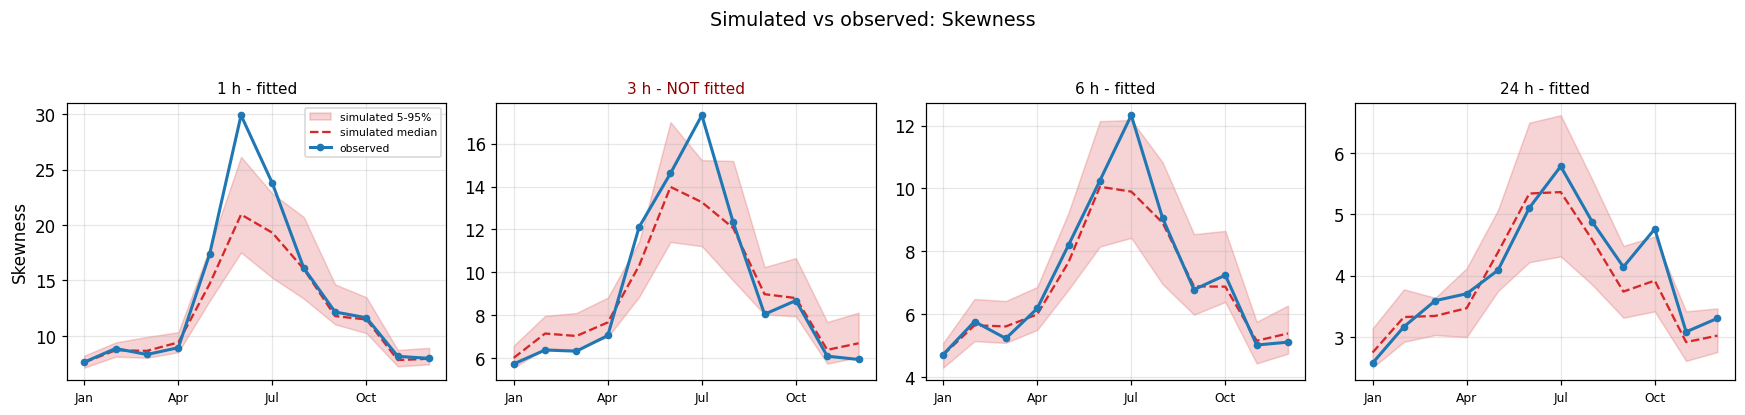

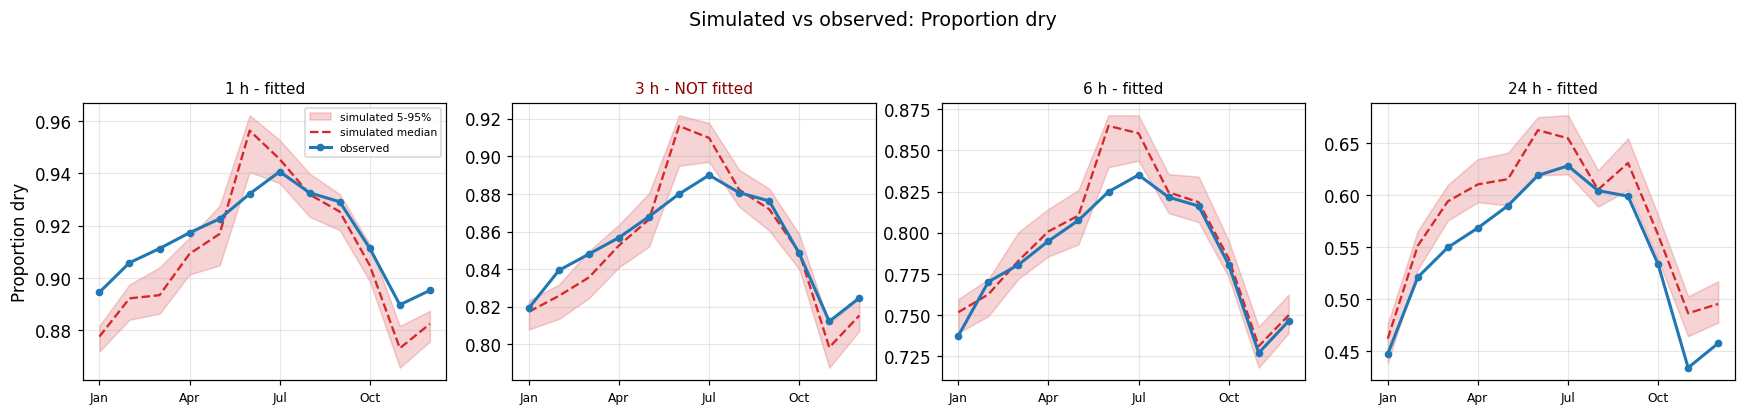

In [14]:
for s in STATS:
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharex=True)
    for ax, h in zip(axes, SCALES_H):
        sims = SIM[s][h]
        ax.fill_between(np.arange(1,13), np.percentile(sims,5,axis=1), np.percentile(sims,95,axis=1),
                        color='#d62728', alpha=0.20, label='simulated 5-95%')
        ax.plot(np.arange(1,13), np.median(sims, axis=1), '--', color='#d62728', lw=1.5, label='simulated median')
        ax.plot(np.arange(1,13), [OBS[m][h][s] for m in range(1,13)], 'o-', color='#1f77b4', lw=2, ms=4, label='observed')
        fitted = h in SCALES_FIT
        ax.set_title(f'{h} h - {"fitted" if fitted else "NOT fitted"}', fontsize=10, color='black' if fitted else '#8B0000')
        ax.set_xticks([1,4,7,10]); ax.set_xticklabels(['Jan','Apr','Jul','Oct'], fontsize=8); ax.grid(alpha=0.3)
    axes[0].set_ylabel(labels[s]); axes[0].legend(fontsize=7)
    plt.suptitle(f'Simulated vs observed: {labels[s]}', y=1.04, fontsize=12.5)
    plt.tight_layout(); show(fig, f'07_sim_{s}')

### Reading the simulation panels

The red band is the 5th–95th percentile of thirty synthetic records; the blue line is the observation. The observation should lie **inside the band**, not on the dashed median: the band is the model's honest statement of how much a 70-year record can vary by chance, so an observation inside it means the real record is a plausible draw from the model.

The 3-hour panels, marked *NOT fitted*, are the ones to point at — nothing in the calibration told the model what to do there.

## 8. Extra validation — six views nobody fitted

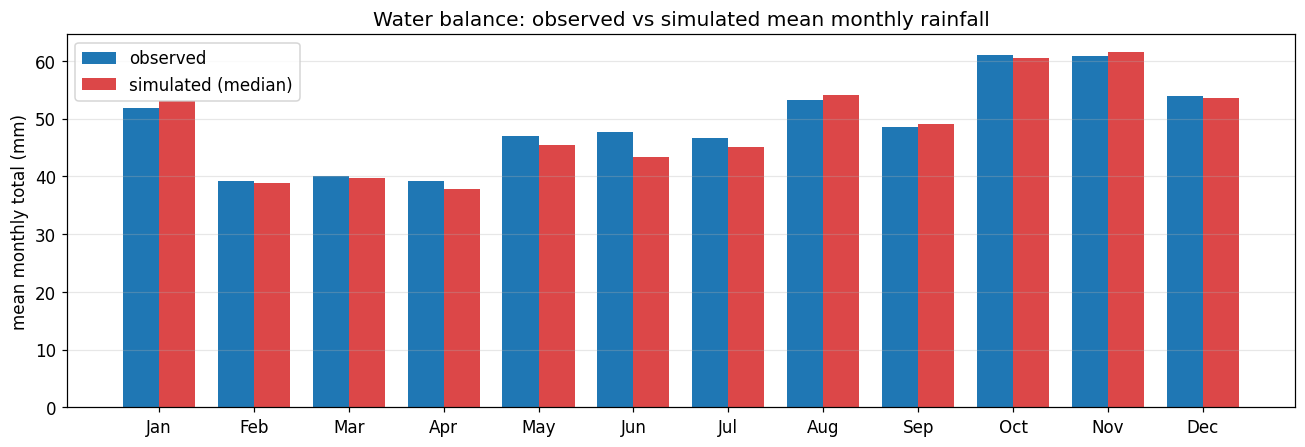

Annual total: observed 590 mm, simulated 582 mm (2.4 % mean monthly error)


In [15]:
SIM_SERIES = {m: simulate_month(m, SEED + 500 + m) for m in range(1, 13)}
sim_all = np.concatenate([SIM_SERIES[m] for m in range(1, 13)])
years_sim = sum(len(blocks_by_year(m, 1))*HOURS_IN_MONTH[m-1] for m in range(1, 13))/8766

obs_tot = [OBS[m][1]['mean']*HOURS_IN_MONTH[m-1] for m in range(1,13)]
sim_tot = [np.median(SIM['mean'][1][m-1])*HOURS_IN_MONTH[m-1] for m in range(1,13)]
fig, ax = plt.subplots(figsize=(12, 4.2)); x = np.arange(1,13); w = 0.38
ax.bar(x-w/2, obs_tot, w, color='#1f77b4', label='observed')
ax.bar(x+w/2, sim_tot, w, color='#d62728', alpha=0.85, label='simulated (median)')
ax.set_xticks(x); ax.set_xticklabels(MONTHS); ax.set_ylabel('mean monthly total (mm)')
ax.set_title('Water balance: observed vs simulated mean monthly rainfall'); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); show(fig, '08_water_balance')
print(f'Annual total: observed {sum(obs_tot):.0f} mm, simulated {sum(sim_tot):.0f} mm '
      f'({np.mean([abs(s-o)/o for s,o in zip(sim_tot,obs_tot)])*100:.1f} % mean monthly error)')

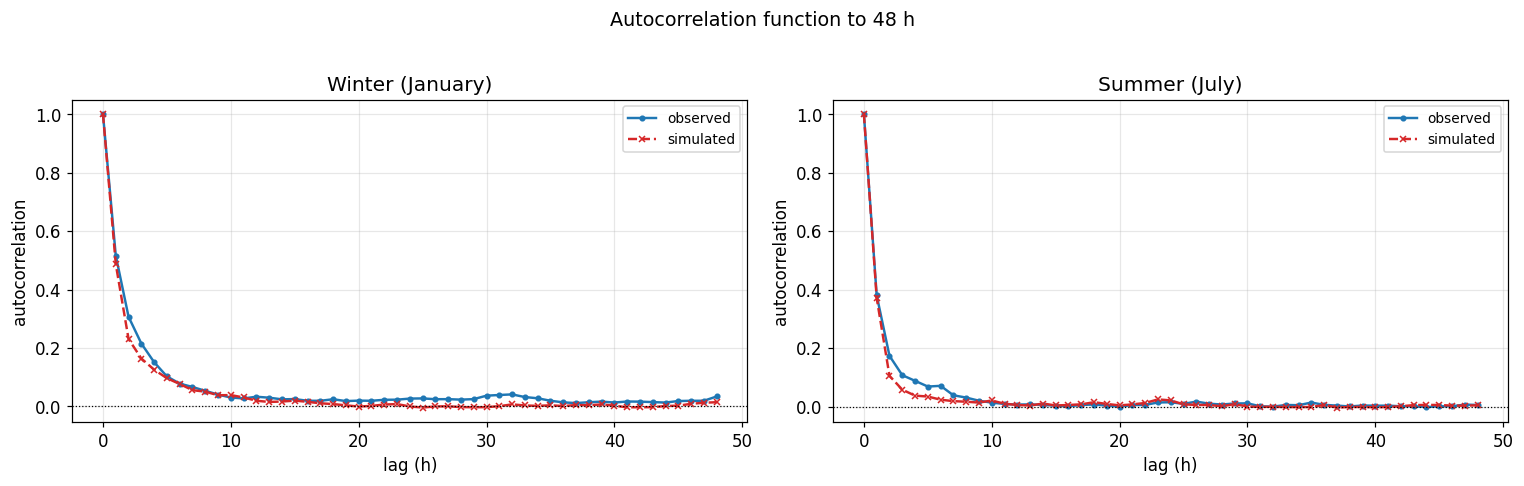

In [16]:
def acf_observed(year_arrays, maxlag):
    allv = np.concatenate(year_arrays); mu = allv.mean(); var = allv.var()
    out = [1.0]
    for k in range(1, maxlag+1):
        num = sum(np.sum((a[:-k]-mu)*(a[k:]-mu)) for a in year_arrays if len(a) > k)
        cnt = sum(len(a)-k for a in year_arrays if len(a) > k)
        out.append(num/(cnt*var))
    return np.array(out)
def acf_series(x, maxlag):
    x = x - x.mean(); var = np.dot(x, x)
    return np.array([1.0] + [np.dot(x[:-k], x[k:])/var for k in range(1, maxlag+1)])

MAXLAG = 48; lags = np.arange(MAXLAG+1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
for ax, (season, m) in zip(axes, [('Winter (January)', 1), ('Summer (July)', 7)]):
    ax.plot(lags, acf_observed(blocks_by_year(m, 1), MAXLAG), 'o-', color='#1f77b4', ms=3, lw=1.6, label='observed')
    ax.plot(lags, acf_series(SIM_SERIES[m], MAXLAG), 'x--', color='#d62728', ms=4, lw=1.6, label='simulated')
    ax.axhline(0, color='k', lw=0.8, ls=':'); ax.set_xlabel('lag (h)'); ax.set_ylabel('autocorrelation')
    ax.set_title(season); ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.suptitle('Autocorrelation function to 48 h', y=1.02, fontsize=12.5)
plt.tight_layout(); show(fig, '09_acf')

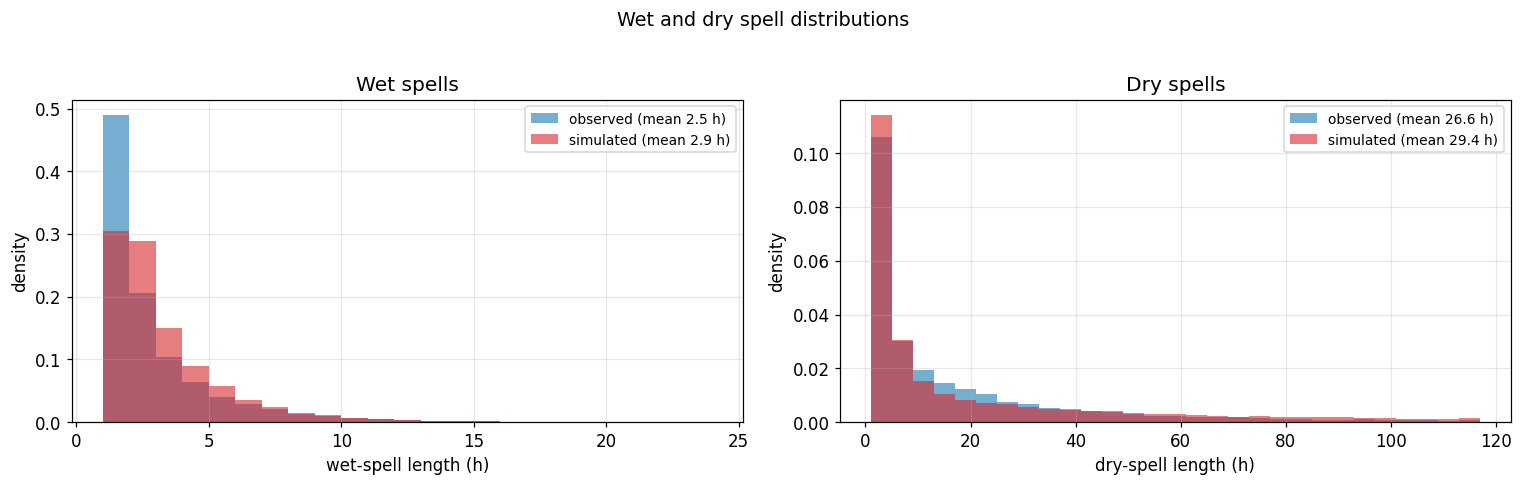

In [17]:
sim_wet, sim_dry = [], []
for m in range(1, 13):
    w_, d_ = spells(SIM_SERIES[m]); sim_wet += list(w_); sim_dry += list(d_)
sim_wet = np.array(sim_wet); sim_dry = np.array(sim_dry)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.3))
ax[0].hist(wet_spells, bins=np.arange(1,25), density=True, alpha=0.6, color='#1f77b4', label=f'observed (mean {wet_spells.mean():.1f} h)')
ax[0].hist(sim_wet, bins=np.arange(1,25), density=True, alpha=0.6, color='#d62728', label=f'simulated (mean {sim_wet.mean():.1f} h)')
ax[0].set_xlabel('wet-spell length (h)'); ax[0].set_ylabel('density'); ax[0].set_title('Wet spells'); ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)
ax[1].hist(dry_spells[dry_spells<120], bins=np.arange(1,120,4), density=True, alpha=0.6, color='#1f77b4', label=f'observed (mean {dry_spells.mean():.1f} h)')
ax[1].hist(sim_dry[sim_dry<120], bins=np.arange(1,120,4), density=True, alpha=0.6, color='#d62728', label=f'simulated (mean {sim_dry.mean():.1f} h)')
ax[1].set_xlabel('dry-spell length (h)'); ax[1].set_ylabel('density'); ax[1].set_title('Dry spells'); ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)
plt.suptitle('Wet and dry spell distributions', y=1.02, fontsize=12.5)
plt.tight_layout(); show(fig, '10_spells')

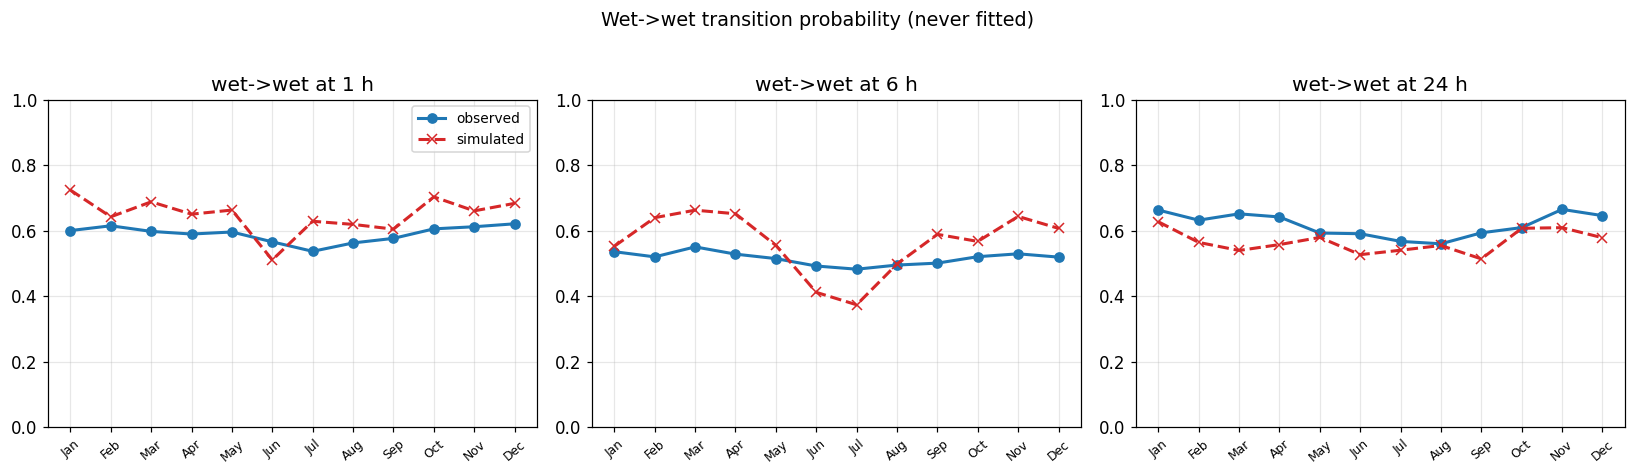

In [18]:
def wet_to_wet(block_lists):
    num = den = 0
    for b in block_lists:
        wet_b = b > 0
        num += int(np.sum(wet_b[:-1] & wet_b[1:])); den += int(np.sum(wet_b[:-1]))
    return num/den if den > 0 else np.nan
def blocks_of(x, h):
    k = len(x)//h; return [x[:k*h].reshape(k, h).sum(axis=1)]

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2)); x = np.arange(1, 13)
for axi, h in zip(ax, [1, 6, 24]):
    obs_t = [wet_to_wet(blocks_by_year(m, h)) for m in range(1,13)]
    sim_t = [wet_to_wet(blocks_of(SIM_SERIES[m], h)) for m in range(1,13)]
    axi.plot(x, obs_t, 'o-', color='#1f77b4', lw=2, label='observed')
    axi.plot(x, sim_t, 'x--', color='#d62728', lw=2, label='simulated')
    axi.set_xticks(x); axi.set_xticklabels(MONTHS, rotation=40, fontsize=8)
    axi.set_ylim(0, 1); axi.set_title(f'wet->wet at {h} h'); axi.grid(alpha=0.3)
    if h == 1: axi.legend(fontsize=9)
plt.suptitle('Wet->wet transition probability (never fitted)', y=1.02, fontsize=12.5)
plt.tight_layout(); show(fig, '11_wet_transition')

### 8.5 Comparing like with like — what the rain gauge can actually record

One question has to be asked about the *instrument* before judging the model on fine detail: **what is the smallest amount of rain this gauge can record?**

In [19]:
obs_wet_int = valid[valid > 0].to_numpy()
distinct = np.unique(np.round(obs_wet_int, 3))
print(f'The eight smallest distinct wet values recorded at Heathrow: {distinct[:8]}')
print(f'Fraction of observed wet hours below 0.1 mm: {(obs_wet_int < 0.1).mean():.4f}')
print(f'Median observed wet hour: {np.median(obs_wet_int):.2f} mm')
print()
print('For contrast, the Bochum gauge (5-minute data) records down to 0.01 mm,')
print('and about 20% of its wet hours fall below 0.1 mm.')

The eight smallest distinct wet values recorded at Heathrow: [0.1  0.2  0.3  0.4  0.5  0.55 0.6  0.7 ]
Fraction of observed wet hours below 0.1 mm: 0.0000
Median observed wet hour: 0.40 mm

For contrast, the Bochum gauge (5-minute data) records down to 0.01 mm,
and about 20% of its wet hours fall below 0.1 mm.


Heathrow's gauge is a **tipping bucket with a 0.1 mm resolution**: the smallest wet value in 74 years is exactly 0.100, the values step in multiples of 0.1, and **not one observed wet hour lies below 0.1 mm**. Real rainfall smaller than half a tip is recorded as **zero**.

The model has no such limitation — it produces a continuous intensity, so it generates hours holding 0.02 or 0.05 mm that the real gauge would have written down as dry. Comparing the model's output directly with the gauge's output compares two different things.

The fix is one line: **apply the gauge's resolution to the simulated series before comparing.**

In [20]:
RESOLUTION = 0.1
def apply_gauge_resolution(x, resolution=RESOLUTION):
    """A tipping-bucket gauge records nothing below half a tip."""
    y = x.copy(); y[y < resolution/2] = 0.0
    return y

rows = []
for label, transform in [('model as generated', lambda s: s),
                         (f'model + {RESOLUTION} mm gauge resolution', apply_gauge_resolution)]:
    events, wets, total_hours = [], [], 0
    for m in range(1, 13):
        x = transform(SIM_SERIES[m])
        events += list(storm_events(x)); wets.append(x[x > 0]); total_hours += len(x)
    events = np.array(events); w = np.concatenate(wets)
    rows.append({'series': label, 'storms per year': round(len(events)/years_sim),
                 'storm duration (h)': round(events.mean(), 1),
                 'median wet hour (mm)': round(float(np.median(w)), 2),
                 'dry-hour fraction': round(1 - len(w)/total_hours, 4)})
rows.append({'series': 'OBSERVED', 'storms per year': round(len(obs_events)/years_effective),
             'storm duration (h)': round(obs_events.mean(), 1),
             'median wet hour (mm)': round(float(np.median(obs_wet_int)), 2),
             'dry-hour fraction': round(float((valid == 0).mean()), 4)})
resolution_table = pd.DataFrame(rows).set_index('series')
resolution_table.to_csv(FIG_DIR/'table3_gauge_resolution.csv')
print('The same model, measured as a 0.1 mm gauge would measure it:')
resolution_table

The same model, measured as a 0.1 mm gauge would measure it:


,storms per year,storm duration (h),median wet hour (mm),dry-hour fraction
series,,,,
model as generated,144,7.5,0.33,0.9090
model + 0.1 mm gauge resolution,142,6.6,0.45,0.9235
OBSERVED,169,6.1,0.40,0.9153


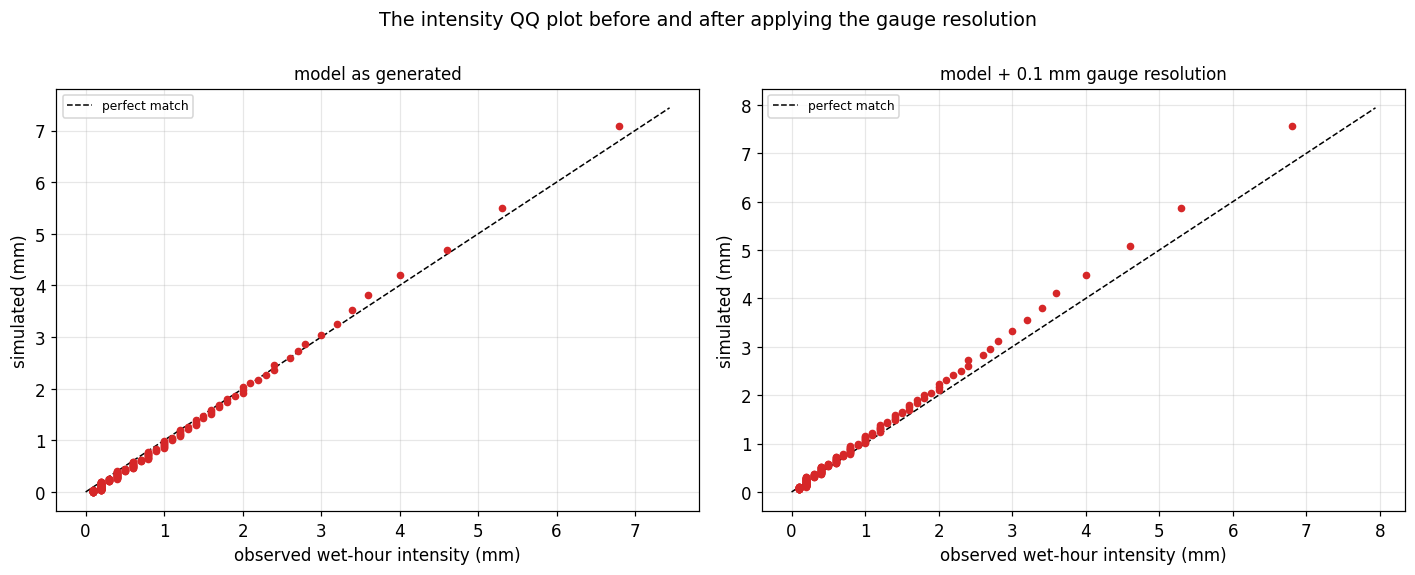

In [21]:
sim_censored = np.concatenate([apply_gauge_resolution(SIM_SERIES[m]) for m in range(1, 13)])
sim_cens_wet = sim_censored[sim_censored > 0]; sim_raw_wet = sim_all[sim_all > 0]
q = np.linspace(1, 99.5, 200); oq = np.percentile(obs_wet_int, q)
fig, ax = plt.subplots(1, 2, figsize=(13, 5.2))
for axi, (data, title) in zip(ax, [(sim_raw_wet, 'model as generated'),
                                   (sim_cens_wet, f'model + {RESOLUTION} mm gauge resolution')]):
    sq = np.percentile(data, q); lim = max(oq.max(), sq.max())*1.05
    axi.plot([0, lim], [0, lim], 'k--', lw=1, label='perfect match')
    axi.plot(oq, sq, 'o', color='#d62728', ms=4)
    axi.set_xlabel('observed wet-hour intensity (mm)'); axi.set_ylabel('simulated (mm)')
    axi.set_title(title, fontsize=11); axi.grid(alpha=0.3); axi.legend(fontsize=8)
plt.suptitle('The intensity QQ plot before and after applying the gauge resolution', y=1.0, fontsize=12.5)
plt.tight_layout(); show(fig, '12_gauge_resolution_qq')

### Reading the six extra checks

The first five — **water balance, autocorrelation to 48 h, wet and dry spells, the intensity QQ plot and the wet→wet transition** — were never calibrated. Only lag-1 autocorrelation and the proportion of dry blocks entered the objective; everything about the *rhythm* of the rainfall (how the dry time is divided into gaps, whether rain follows rain, how the whole intensity distribution is shaped) is free. Reproducing them is the strongest argument for a mechanistic generator: a model built from storms and cells inherits the event structure of real rainfall because that structure is what it is made of.

The sixth, **the gauge-resolution test**, is a methodological point rather than a model test, and it applies to every tipping-bucket record:

- the **median wet hour** and the **mean storm duration** both move towards the observations once the model is measured the way the gauge measures the sky. The mechanism is intuitive: sub-resolution drizzle acts as a *bridge*, joining two real storms into one long simulated event — remove what the instrument could not see, and the storms separate.
- **One subtlety to have ready if asked**: after censoring, the dry-hour fraction shifts slightly relative to the observed one. This is not a contradiction but a known refinement — we calibrated the model so that its probability of *exactly zero rain* matches the gauge's probability of *recording zero*, and those are not the same event, since the gauge also writes zero when it rains less than 0.1 mm. Treating the observations as **censored** rather than exactly dry is the accepted correction.

## 9. Storms and extremes

In [22]:
sim_events = []
for m in range(1, 13): sim_events += list(storm_events(SIM_SERIES[m]))
sim_events = np.array(sim_events)
sim_events_cens = []
for m in range(1, 13): sim_events_cens += list(storm_events(apply_gauge_resolution(SIM_SERIES[m])))
sim_events_cens = np.array(sim_events_cens)
print(f'Storms per year : observed {len(obs_events)/years_effective:5.0f}   simulated {len(sim_events)/years_sim:5.0f}   '
      f'simulated at gauge resolution {len(sim_events_cens)/years_sim:5.0f}')
print(f'Storm duration  : observed {obs_events.mean():5.1f} h  simulated {sim_events.mean():5.1f} h  '
      f'simulated at gauge resolution {sim_events_cens.mean():5.1f} h')
print('(nothing in the calibration mentioned storms - the fit only ever saw moments of aggregated totals)')

Storms per year : observed   169   simulated   144   simulated at gauge resolution   142
Storm duration  : observed   6.1 h  simulated   7.5 h  simulated at gauge resolution   6.6 h
(nothing in the calibration mentioned storms - the fit only ever saw moments of aggregated totals)


70 complete years used for the observed annual maxima


50 synthetic 70-year records in 3 s


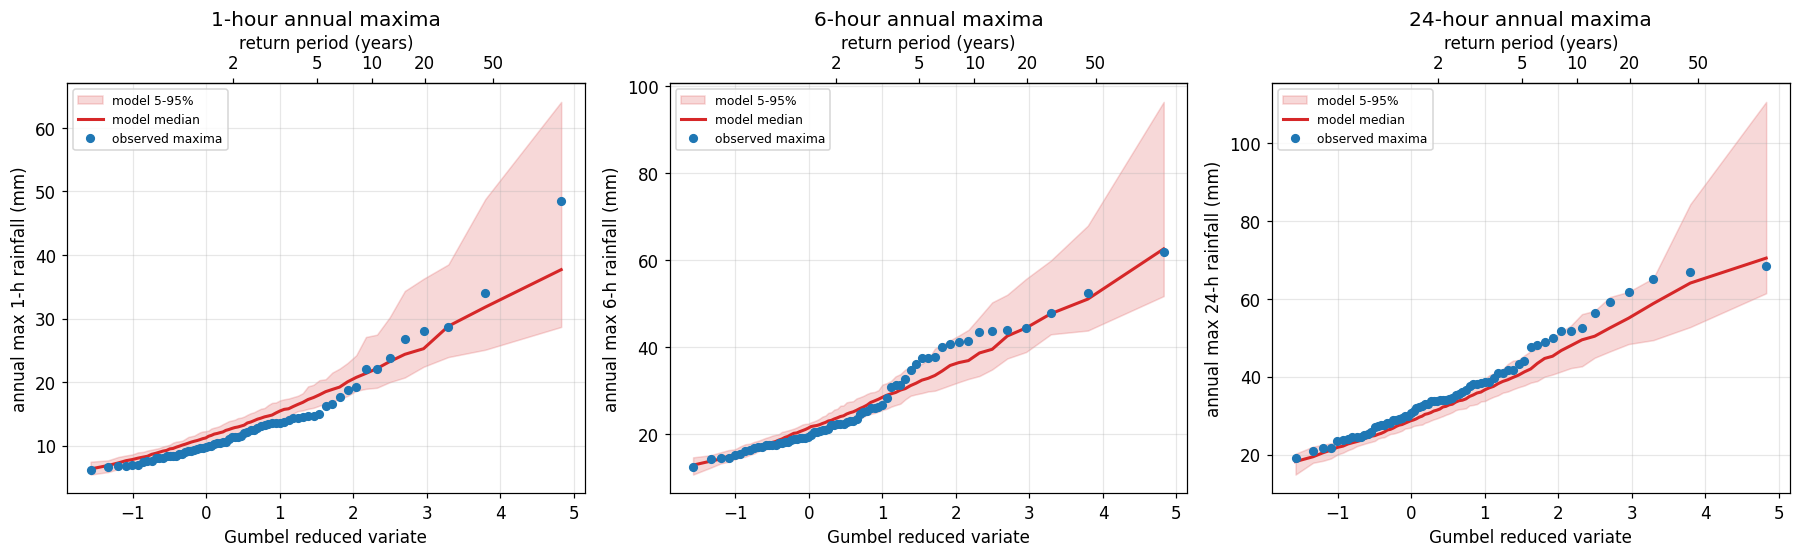

In [23]:
complete_years = [int(y) for y, g in rain.groupby(rain.index.year)
                  if np.isfinite(g.to_numpy()).all() and len(g) >= 8600]
NY = len(complete_years)
obs_max = {}
for h in [1, 6, 24]:
    rolled = rain if h == 1 else rain.rolling(h).sum()
    obs_max[h] = np.sort(rolled.groupby(rolled.index.year).max().loc[complete_years].dropna().to_numpy())
print(f'{NY} complete years used for the observed annual maxima')

N_EXT = 50; t0 = time.time()
sim_max = {h: np.zeros((N_EXT, NY)) for h in [1, 6, 24]}
for r in range(N_EXT):
    best = {h: np.zeros(NY) for h in [1, 6, 24]}
    for m in range(1, 13):
        dpm = int(round(HOURS_IN_MONTH[m-1]/24)); n_hours = NY*dpm*24
        lam_, iota_, alpha_, nu_, kappa_, phi_ = FIT[m][0]
        mdl = BLRPRx(params=BLRPRx_params(lam_, phi_, kappa_, alpha_, nu_, 1.0, iota_),
                     sampling_rng=np.random.default_rng(SEED + r*100 + m))
        hh = bin_to_hours(mdl.sample(duration_hr=n_hours), n_hours).reshape(NY, dpm*24)
        best[1] = np.maximum(best[1], hh.max(axis=1))
        cums = np.cumsum(np.concatenate([np.zeros((NY,1)), hh], axis=1), axis=1)
        for h in (6, 24): best[h] = np.maximum(best[h], (cums[:, h:]-cums[:, :-h]).max(axis=1))
    for h in [1, 6, 24]: sim_max[h][r] = np.sort(best[h])
print(f'{N_EXT} synthetic {NY}-year records in {time.time()-t0:.0f} s')

y_pos = -np.log(-np.log((np.arange(1, NY+1)-0.44)/(NY+0.12)))
T_marks = [2, 5, 10, 20, 50]; y_marks = [-np.log(-np.log(1-1/T)) for T in T_marks]
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.2))
for ax, h in zip(axes, [1, 6, 24]):
    ax.fill_between(y_pos, np.percentile(sim_max[h],5,axis=0), np.percentile(sim_max[h],95,axis=0),
                    color='#d62728', alpha=0.18, label='model 5-95%')
    ax.plot(y_pos, np.percentile(sim_max[h],50,axis=0), '-', color='#d62728', lw=2, label='model median')
    ax.plot(y_pos, obs_max[h], 'o', color='#1f77b4', ms=5, label='observed maxima')
    ax.set_xlabel('Gumbel reduced variate'); ax.set_ylabel(f'annual max {h}-h rainfall (mm)')
    ax.set_title(f'{h}-hour annual maxima'); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='upper left')
    top = ax.secondary_xaxis('top'); top.set_xticks(y_marks); top.set_xticklabels([str(T) for T in T_marks])
    top.set_xlabel('return period (years)')
plt.tight_layout(); show(fig, '13_gumbel')

In [24]:
def gumbel_fit(sorted_maxima):
    beta = sorted_maxima.std()*np.sqrt(6)/np.pi
    return sorted_maxima.mean() - 0.5772157*beta, beta
rows = []
for h in [1, 6, 24]:
    u_o, b_o = gumbel_fit(obs_max[h])
    for T in T_marks:
        yT = -np.log(-np.log(1-1/T))
        levels = [gumbel_fit(sim_max[h][r])[0] + gumbel_fit(sim_max[h][r])[1]*yT for r in range(N_EXT)]
        rows.append({'Scale': f'{h} h', 'T (yr)': T, 'Observed-Gumbel (mm)': round(u_o + b_o*yT, 1),
                     'Model median (mm)': round(float(np.median(levels)), 1),
                     'Model 5-95% (mm)': f'{np.percentile(levels,5):.1f} - {np.percentile(levels,95):.1f}'})
return_table = pd.DataFrame(rows).set_index(['Scale','T (yr)'])
return_table.to_csv(FIG_DIR/'return_levels.csv')
print('Return levels - the rainfall depth expected once every T years:')
return_table

Return levels - the rainfall depth expected once every T years:


Observed-Gumbel (mm)  Model median (mm) Model 5-95% (mm)
Scale T (yr)                                                          
1 h   2                       12.0               13.2      12.1 - 14.5
      5                       18.2               18.5      16.9 - 23.6
      10                      22.3               22.0      19.5 - 29.4
      20                      26.3               25.4      22.0 - 35.0
      50                      31.4               29.9      25.2 - 42.3
6 h   2                       24.2               24.3      22.4 - 26.4
      5                       33.5               32.7      29.9 - 39.0
      10                      39.7               38.6      34.8 - 46.8
      20                      45.6               44.1      39.4 - 54.2
      50                      53.2               51.3      45.3 - 63.8
24 h  2                       34.4               32.0      30.5 - 34.3
      5                       44.5               41.9      38.7 - 47.4
      10                      51.2               48.2      43.9 - 56.6
      20                      57.6               54.3      48.9 - 65.1
      50                      65.9               62.2      55.4 - 76.2

### Reading the storms and the extremes

**Storms.** Simulated and observed events are measured by the *same* 6-hour-gap rule, so the comparison is fair even though a "model storm" and an "observed event" are different objects (model storms can overlap; one long observed event may contain two model storms). The line measured at gauge resolution is the one to quote, for the reason given in Section 8.5.

**Extremes.** Annual maxima are plotted so a Gumbel distribution appears as a straight line, with the return period on the top axis. Nothing here was fitted — annual maxima never entered the objective — which makes this the model's most demanding test and the one design engineers care about most.

The pattern expected for this model family, and seen at all three stations of this dissertation, is good agreement through the ordinary return periods and a **shortfall at the rarest events**. The cause is structural: cell intensities are drawn from an exponential distribution whose light tail makes very large values too unlikely, whereas real convective rainfall has a heavier tail. This is exactly the motivation for the heavy-tailed and sinusoidal-pulse refinements of Kim & Onof (2020) and Tai et al. (2025); finding it here reproduces a known frontier rather than discovering a new fault. The practical reading for design use: reliable in the ordinary range, and a **lower bound** at the rare end.

## 10. Conclusions

1. **The record had to be quality-controlled before it could be modelled.** The file contains no missing values because eight consecutive months of gauge failure in 1988 — and five isolated winter months — were written down as zeros. They were found by a physical argument (a maritime month cannot be completely dry), not by reading the file, and masking them corrects the annual total to 590 mm and the dry-hour fraction to 0.915.
2. **One parameter set per month** (Table 1), obtained by fitting **all five properties at 1, 6 and 24 h** — nothing excluded — with the storm rate held inside the range the literature reports. At this station the range turned out to be inactive: all twelve months settled strictly inside it, so the data determined the storm rate unaided. The severe identifiability failure reported in earlier Heathrow notebooks was a separate matter entirely — a mis-called library function, corrected and verified against simulation in Section 4.
3. **The mechanistic translation** (Table 2) turns the fit into physics: Heathrow's rainfall arrives as comparatively infrequent storms, made of many weak long cells in winter and a few intense short ones in summer, with the water per storm staying of the same order all year.
4. **The validation holds beyond the fit**: the 3-hour statistics (never fitted), the water balance, the autocorrelation function to 48 h, the spell distributions and the wet→wet transition are all reproduced without being calibrated.
5. **Measurement and model must be compared on the same footing** (Section 8.5). Heathrow's gauge cannot record less than 0.1 mm while the model emits a continuous intensity; applying the instrument's resolution to the simulated series moves the median wet hour and the storm duration towards the observations. The lesson generalises to every tipping-bucket record in this dissertation.
6. **For the cross-station chapter**, Heathrow's message in one sentence: *the driest of the three stations is not the one with the weakest rain — its wet hours are heavier than Manchester's — it is the one where rain arrives least often, and the calibrated storm frequency says exactly that.*

In [25]:
print('Artefacts saved to', FIG_DIR.resolve(), ':')
for f in sorted(os.listdir(FIG_DIR)): print('  ', f)
print('\nNotebook complete - Heathrow v9.')

Artefacts saved to C:\Users\rajab\OneDrive\Bureau\DISSERTATION\Claude\outputs\heathrow_v9 :
   01_qc.png
   02_climatology.png
   03_diurnal.png
   04_observed_stats.png
   05_mechanistic_cycle.png
   06_fit_quality.png
   07_sim_ar1.png
   07_sim_mean.png
   07_sim_pdry.png
   07_sim_skew.png
   07_sim_var.png
   08_water_balance.png
   09_acf.png
   10_spells.png
   11_wet_transition.png
   12_gauge_resolution_qq.png
   13_gumbel.png
   observed_statistics.csv
   return_levels.csv
   table1_parameters.csv
   table2_mechanistic.csv
   table3_gauge_resolution.csv

Notebook complete - Heathrow v9.
